# Pointing Reconstruction

The goal: recover the true focal plane layout from a planet scan and compare it to the ground truth positions in the calibration file. Per detector maps makes its own small map of Jupiter using only the boresight pointing (no focal plane offsets). Jupiter will show up in each detector's map at a position that corresponds to that detector's actual offset from the boresight.

At each time sample, we take Jupiter's fixed sky position and rotate it into the telescope's own reference frame using the boresight quaternion. This gives us coordinates (du, dv) where Jupiter appears from inside the telescope at that moment. When detector i happens to be pointing directly at Jupiter, (du, dv) equals that detector's focal plane position (xi_i, eta_i) exactly. So after accumulating all the samples, the peak of the map tells us where the detector actually is.

In simulation, the reconstructed positions should match the ground truth from the calibration file almost exactly.

In [2]:
#!pip install h5py

In [3]:
import sys
import io
import pathlib
import tomllib

import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.spatial.transform import Rotation
from spt3g import core

sys.path.insert(0, str(pathlib.Path('..').resolve()))

from mapmaker.reader import iter_g3_chunks
from mapmaker.binning import bin_detector, make_map_edges
from mapmaker.cleaning import clean_tod

In [4]:
# Load config and resolve paths relative to the mapmaker directory
config_path = pathlib.Path('../config.toml').resolve()
with open(config_path, 'rb') as f:
    cfg = tomllib.load(f)

cfg_dir = config_path.parent
cfg['data']['input_dirs'] = [
    str((cfg_dir / d).resolve()) if not pathlib.Path(d).is_absolute() else d
    for d in cfg['data']['input_dirs']
]

# Jupiter's position, set from ephemeris in the next cell.
# This acts as a default value if the ephemeris is not available, reading directly from the congfig file.
# NOTE: in the mapmaker, the center might become dynamic so must be adjusted!
RA_SRC  = cfg['map']['ra0_deg']
DEC_SRC = cfg['map']['dec0_deg']
print(f'Fallback position (from config): RA={RA_SRC:.4f} deg  Dec={DEC_SRC:.4f} deg')

# Currently set to use the full observation, short windows miss detectors at the edges of the focal plane?
# This is considered here to do a future study: how many passes & time can we get good enough estimates??
cfg['pipeline']['start_offset_s'] = 0.0
cfg['pipeline']['max_duration_s']  = None

# Reconstruction map parameters (for the map-based approach)
RECON_XLEN       = 2.0   # degrees, needs to cover full focal plane (~1.4 deg diameter)
RECON_YLEN       = 2.0
RECON_RES_ARCMIN = 1.0   # arcmin/pixel

SNR_THRESHOLD = 5.0   # for MAP-BASED, NOTE: arbitray chosen value (subject to change w real data)
# it might be a good idea to implement a function to do subsets of the detectors when we have multiple arrays

Fallback position (from config): RA=142.0000 deg  Dec=15.6000 deg


Used in the simuation:

- "site_alt_m" (spt3g.core.G3Double) => 5610
- "site_class" (spt3g.core.G3String) => "toast.instrument.GroundSite"
- "site_lat_deg" (spt3g.core.G3Double) => -22.986
- "site_lon_deg" (spt3g.core.G3Double) => -67.74
- "site_name" (spt3g.core.G3String) => "Cerro-Chajnantor"
- "site_uid" (spt3g.core.G3Int) => 3975474032
- "site_weather_max_pwv" (spt3g.core.G3Double) => 1.41
- "site_weather_name" (spt3g.core.G3String) => "atacama"
- "site_weather_realization" (spt3g.core.G3Int) => 0
- "site_weather_time" (spt3g.core.G3Time) => 01-Oct-2026:11:20:30.000000000
- "site_weather_uid" (spt3g.core.G3Int) => 3975474032
- "site_weather_use_median" (spt3g.core.G3Bool) => False

USING from the Wikipedia: https://geohack.toolforge.org/geohack.php?pagename=Fred_Young_Submillimeter_Telescope&params=22.98592_S_67.74028_W_

- DMS 22° 59′ 9.31″ S, 67° 44′ 25.01″ W
- Decimal	-22.98592, -67.74028

In [5]:
from astropy.time import Time
from astropy.coordinates import EarthLocation, get_body
import astropy.units as u

# FYST site on Cerro Chajnantor
_fyst_site = EarthLocation(lat=-22.98592 * u.deg, lon=-67.74028 * u.deg, height=5610 * u.m)

# Check the first chunk to get observation start time.
# Timestamps from the simulation are Unix epoch (seconds since 1970-01-01 00:00:00 UTC).
_first_chunk = next(iter_g3_chunks(cfg))
_t_obs = Time(_first_chunk.t_start, format='unix', scale='utc')
print(f'Scan start (UTC):    {_t_obs.iso}')

# Apparent position of Jupiter at scan start.
# Jupiter moves <2 arcsec over a 20-min scan so scan-start is sufficient.
# Note that for 850 GHz or longer scans, pass per-detector peak timestamps here!
_jup = get_body('jupiter', _t_obs, _fyst_site)
print (_jup)
print (_jup.ra, _jup.ra.deg)
RA_SRC  = _jup.ra.deg
DEC_SRC = _jup.dec.deg

#_dra  = (RA_SRC  - cfg['map']['ra0_deg']) * 3600
#_ddec = (DEC_SRC - cfg['map']['dec0_deg']) * 3600
print(f'Jupiter (ephemeris): RA={RA_SRC:.6f} deg  Dec={DEC_SRC:.6f} deg')
#print(f'Jupiter (config):    RA={cfg["map"]["ra0_deg"]:.6f} deg  Dec={cfg["map"]["dec0_deg"]:.6f} deg')
#print(f'Offset from config:  ΔRA={_dra:+.3f} arcsec  ΔDec={_ddec:+.3f} arcsec')

# from the docs:
# fyst_trajectories equivalent (once installed):
#   site   = ft.get_fyst_site()
#   coords = ft.Coordinates(site, atmosphere=ft.AtmosphericConditions.for_fyst())
#   r, d   = coords.altaz_to_radec(az_jup, el_jup, obstime=_t_obs)


Scan start (UTC):    2026-10-01 11:10:00.000
<SkyCoord (GCRS: obstime=1790853000.0, obsgeoloc=(-1980648.5827592, 5538485.59925081, -2472469.32825517) m, obsgeovel=(-403.87708845, -143.9591965, 1.06073962) m / s): (ra, dec, distance) in (deg, deg, AU)
    (141.90774773, 15.60228552, 5.91523934)>
141d54m27.89183766s 141.90774773268288
Jupiter (ephemeris): RA=141.907748 deg  Dec=15.602286 deg


## 1. Ground truth focal plane layout

Read the calibration frame from the G3 files and convert detector quaternions to focal plane (x, y) positions in degrees.

Using this as a comparison.

In [6]:
import glob

def load_nominal_focal_plane(cfg):
    """Return {det_name: (x_deg, y_deg)} ground truth positions from the calibration frame."""
    g3_files = []
    for pattern in cfg['data']['input_dirs']:
        for d in sorted(glob.glob(pattern)):
            g3_files.extend(sorted(pathlib.Path(d).rglob('*.g3')))

    for path in g3_files:
        for frame in core.G3File(str(path)):
            if frame.type != core.G3FrameType.Calibration:
                continue

            fp_buffer = io.BytesIO(bytes(frame['focalplane']))
            with h5py.File(fp_buffer, 'r') as f:
                names = [n.decode('utf-8') for n in f['focalplane']['name'][:]]
                quats = np.asarray(f['focalplane']['quat'][:], dtype=np.float64)

            # Rotate z-axis by each detector quaternion -> unit direction vector
            dirs = Rotation.from_quat(quats).apply(np.array([0., 0., 1.]))

            # Convert direction vector to focal plane (x, y) in degrees
            # theta = total angular offset from boresight
            # x = theta * cos(phi),  y = theta * sin(phi)
            theta = np.degrees(np.arccos(np.clip(dirs[:, 2], -1.0, 1.0)))
            phi   = np.arctan2(dirs[:, 1], dirs[:, 0])
            x_deg = theta * np.cos(phi)
            y_deg = theta * np.sin(phi)

            return {name: (x, y) for name, x, y in zip(names, x_deg, y_deg)}

    raise RuntimeError('No calibration frame found')


nominal = load_nominal_focal_plane(cfg)
print(f'Loaded {len(nominal)} detectors')

nom_names = list(nominal.keys())
nom_x = np.array([nominal[n][0] for n in nom_names])
nom_y = np.array([nominal[n][1] for n in nom_names])

#print (nom_x)

print(f'Focal plane extent: x=[{nom_x.min():.3f}, {nom_x.max():.3f}] deg  '
      f'y=[{nom_y.min():.3f}, {nom_y.max():.3f}] deg')

Loaded 3426 detectors
Focal plane extent: x=[-0.602, -0.019] deg  y=[-0.151, 0.504] deg


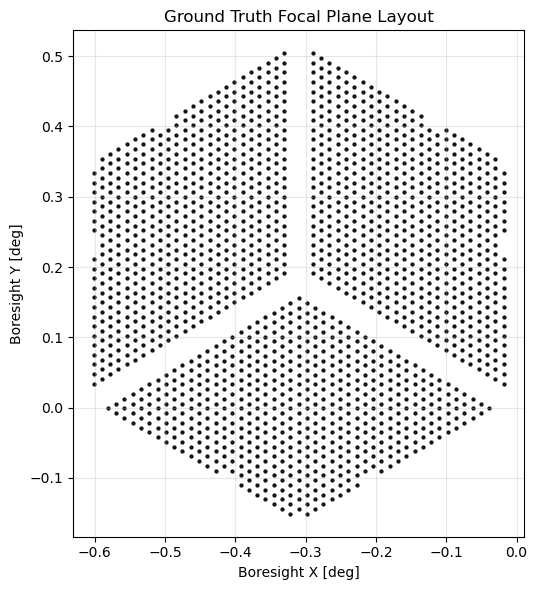

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(nom_x, nom_y, s=4, c='k', alpha=0.6)
ax.set_xlabel('Boresight X [deg]')
ax.set_ylabel('Boresight Y [deg]')
ax.set_title('Ground Truth Focal Plane Layout')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Method A, Map-based

For each detector, bin its signal into a 2D focal plane map using the boresight quaternion to project Jupiter's sky position into the focal plane frame. The peak pixel of each detector's map gives its reconstructed focal plane position.

In [8]:
# Focal plane coordinate grid centred at the 0,0
# This method is just peak pixel
recon_res_deg = RECON_RES_ARCMIN / 60.0
fp_edges_u, fp_edges_v = make_map_edges(
    ra0_deg=0.0, dec0_deg=0.0,
    xlen_deg=RECON_XLEN, ylen_deg=RECON_YLEN,
    res_deg=recon_res_deg,
)
ny = len(fp_edges_v) - 1
nx = len(fp_edges_u) - 1
print(f'Reconstruction grid: {ny} x {nx} pixels at {RECON_RES_ARCMIN:.1f} arcmin/pixel')
print(f'Memory estimate: {len(nominal) * ny * nx * 4 / 1e6:.0f} MB per array (data + hits = x2)')

Reconstruction grid: 120 x 120 pixels at 1.0 arcmin/pixel
Memory estimate: 197 MB per array (data + hits = x2)


In [9]:
src_vec = np.array([
    np.cos(np.radians(DEC_SRC)) * np.cos(np.radians(RA_SRC)),
    np.cos(np.radians(DEC_SRC)) * np.sin(np.radians(RA_SRC)),
    np.sin(np.radians(DEC_SRC))
])

print (src_vec)
print (RA_SRC)

[-0.75801827  0.59419674  0.26895824]
141.90774773268288


In [10]:
import time

# real data likey wouldn't have this string of names
all_kids = list(nominal.keys())
selected = all_kids
print(selected)

n_sel = len(selected)
kid_to_j = {k: j for j, k in enumerate(selected)}
print (kid_to_j)
print(f'Mapping {n_sel} detectors')

det_data = np.zeros((n_sel, ny, nx), dtype=np.float32)
det_hits = np.zeros((n_sel, ny, nx), dtype=np.float32)

n_chunks = 0
t0 = time.perf_counter()
print (t0)
kid_to_i = None  # maps detector name -> column in chunk.signal, populated on first chunk

pipe_cfg = cfg['pipeline']
print (pipe_cfg)


['w2_p0000_PC_f280_A', 'w2_p0000_PC_f280_B', 'w2_p0001_PC_f280_A', 'w2_p0001_PC_f280_B', 'w2_p0002_PC_f280_A', 'w2_p0002_PC_f280_B', 'w2_p0003_PC_f280_A', 'w2_p0003_PC_f280_B', 'w2_p0004_PC_f280_A', 'w2_p0004_PC_f280_B', 'w2_p0005_PC_f280_A', 'w2_p0005_PC_f280_B', 'w2_p0006_PC_f280_A', 'w2_p0006_PC_f280_B', 'w2_p0007_PC_f280_A', 'w2_p0007_PC_f280_B', 'w2_p0008_PC_f280_A', 'w2_p0008_PC_f280_B', 'w2_p0009_PC_f280_A', 'w2_p0009_PC_f280_B', 'w2_p0010_PC_f280_A', 'w2_p0010_PC_f280_B', 'w2_p0011_PC_f280_A', 'w2_p0011_PC_f280_B', 'w2_p0012_PC_f280_A', 'w2_p0012_PC_f280_B', 'w2_p0013_PC_f280_A', 'w2_p0013_PC_f280_B', 'w2_p0014_PC_f280_A', 'w2_p0014_PC_f280_B', 'w2_p0015_PC_f280_A', 'w2_p0015_PC_f280_B', 'w2_p0016_PC_f280_A', 'w2_p0016_PC_f280_B', 'w2_p0017_PC_f280_A', 'w2_p0017_PC_f280_B', 'w2_p0018_PC_f280_A', 'w2_p0018_PC_f280_B', 'w2_p0019_PC_f280_A', 'w2_p0019_PC_f280_B', 'w2_p0020_PC_f280_A', 'w2_p0020_PC_f280_B', 'w2_p0021_PC_f280_A', 'w2_p0021_PC_f280_B', 'w2_p0022_PC_f280_A', 'w2_p0022

In [11]:
for chunk in iter_g3_chunks(cfg):
    if kid_to_i is None:
        kid_to_i = {k: i for i, k in enumerate(chunk.kids)}

    # Project Jupiter into the focal plane frame at each time sample.
    boresight_r = Rotation.from_quat(chunk.boresight_q)
    src_fp = boresight_r.inv().apply(src_vec)  # (n_samps, 3)
    du = np.degrees(np.arctan2(src_fp[:, 0], src_fp[:, 2]))
    dv = np.degrees(np.arctan2(src_fp[:, 1], src_fp[:, 2]))

    baseline = np.median(chunk.signal, axis=0)
    sig = chunk.signal - baseline[np.newaxis, :]
    #sig = clean_tod(sig, chunk.sample_rate,
    #                cosmic_rays=pipe_cfg['clean_cosmic_rays'],
    #                highpass_hz=pipe_cfg['highpass_cutoff_hz'])

    for kid in selected:
        if kid not in kid_to_i:
            continue
        i = kid_to_i[kid]
        j = kid_to_j[kid]
        d, h = bin_detector(sig[:, i], du, dv, fp_edges_u, fp_edges_v)
        det_data[j] += d.astype(np.float32)
        det_hits[j] += h.astype(np.float32)

    n_chunks += 1
    if n_chunks % 10 == 0:
        print(f'  chunk {n_chunks}...', end='\r')

print(f'\nDone: {n_chunks} chunks in {time.perf_counter() - t0:.1f}s')

  chunk 1260...
Done: 1260 chunks in 618.6s


## 3. Peak extraction

For each detector's map, find the peak pixel. The peak position in (u, v) directly gives the detector's focal plane position (xi_i, eta_i).

In [12]:
u_centres = 0.5 * (fp_edges_u[:-1] + fp_edges_u[1:])
v_centres = 0.5 * (fp_edges_v[:-1] + fp_edges_v[1:])

BORDER_PIX    = 5   # reject argmax within this many pixels of the map edge
MIN_PEAK_HITS = 5   # argmax pixel must have at least this many samples

recon_x = np.full(n_sel, np.nan)
recon_y = np.full(n_sel, np.nan)
snr     = np.full(n_sel, np.nan)

for j in range(n_sel):
    with np.errstate(invalid='ignore', divide='ignore'):
        m = np.where(det_hits[j] > 0, det_data[j] / det_hits[j], np.nan)

    if not np.any(np.isfinite(m)):
        continue

    flat_idx = np.nanargmax(m)
    iy, ix   = np.unravel_index(flat_idx, m.shape)

    # Reject map-edge peaks (noise artefacts) and under-sampled peaks
    if (ix < BORDER_PIX or ix >= nx - BORDER_PIX or
            iy < BORDER_PIX or iy >= ny - BORDER_PIX):
        continue
    if det_hits[j, iy, ix] < MIN_PEAK_HITS:
        continue

    # Estimate noise from the lower half of the map (pixels below the median)
    off_mask = np.isfinite(m) & (m < np.nanpercentile(m[np.isfinite(m)], 50))
    noise    = float(np.sqrt(np.nanmean(m[off_mask] ** 2))) if off_mask.any() else np.nan
    peak_snr = float(np.nanmax(m)) / noise if (noise is not None and noise > 0) else np.nan
    snr[j]   = peak_snr

    if np.isnan(peak_snr) or peak_snr < SNR_THRESHOLD:
        continue

    recon_x[j] = u_centres[ix]
    recon_y[j] = v_centres[iy]

valid = np.isfinite(recon_x) & np.isfinite(recon_y)
print(f'Valid peaks (SNR > {SNR_THRESHOLD}): {valid.sum()} / {n_sel}')
print(f'SNR distribution -- median: {np.nanmedian(snr):.1f}, '
      f'10th pct: {np.nanpercentile(snr, 10):.1f}, '
      f'90th pct: {np.nanpercentile(snr, 90):.1f}')


Valid peaks (SNR > 5.0): 3426 / 3426
SNR distribution -- median: 10075.9, 10th pct: 4515.4, 90th pct: 15248.3


### Method A results: Ground truth vs reconstructed

Just the peak pixel map based method

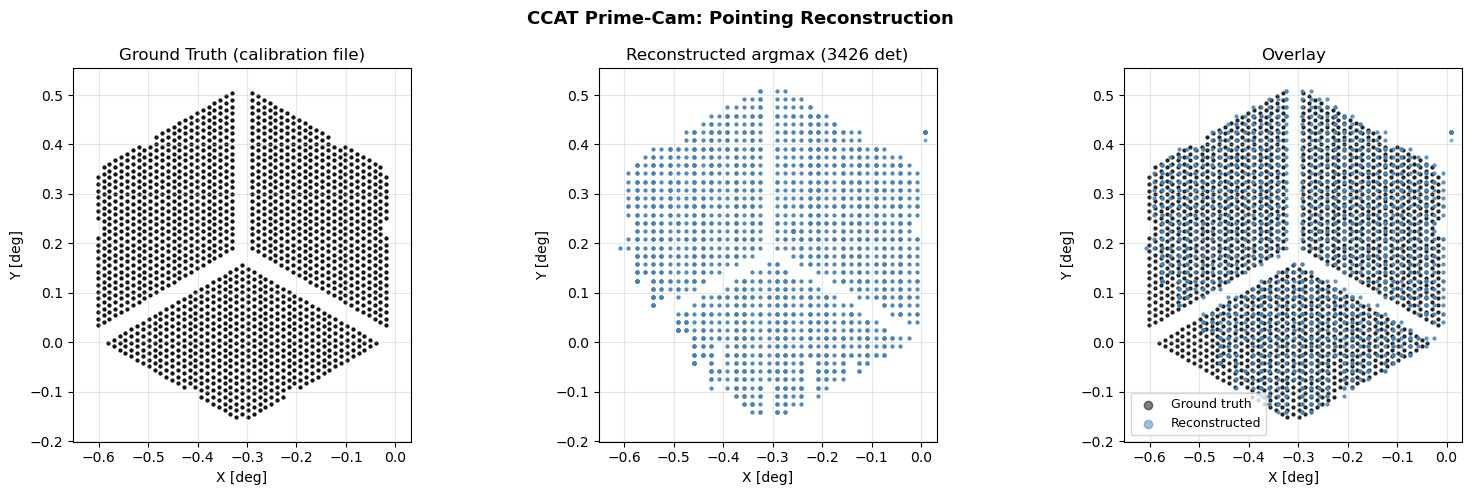

In [13]:
nom_x_sel = np.array([nominal[k][0] for k in selected])
nom_y_sel = np.array([nominal[k][1] for k in selected])

margin = 0.05   # deg padding around ground truth extent
xlim = (nom_x_sel.min() - margin, nom_x_sel.max() + margin)
ylim = (nom_y_sel.min() - margin, nom_y_sel.max() + margin)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(nom_x_sel, nom_y_sel, s=4, c='k', alpha=0.6)
ax.set_title('Ground Truth (calibration file)')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(recon_x[valid], recon_y[valid], s=4, c='steelblue', alpha=0.6)
ax.set_title(f'Reconstructed argmax ({valid.sum()} det)')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(nom_x_sel[valid], nom_y_sel[valid], s=4, c='k', alpha=0.5, label='Ground truth')
ax.scatter(recon_x[valid],   recon_y[valid],   s=4, c='steelblue', alpha=0.5, label='Reconstructed')
ax.set_title('Overlay')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.legend(markerscale=3, fontsize=9)

fig.suptitle('CCAT Prime-Cam: Pointing Reconstruction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Residuals (reconstructed - ground truth):
  X: mean=0.98  std=3.70 arcmin
  Y: mean=0.66  std=2.87 arcmin


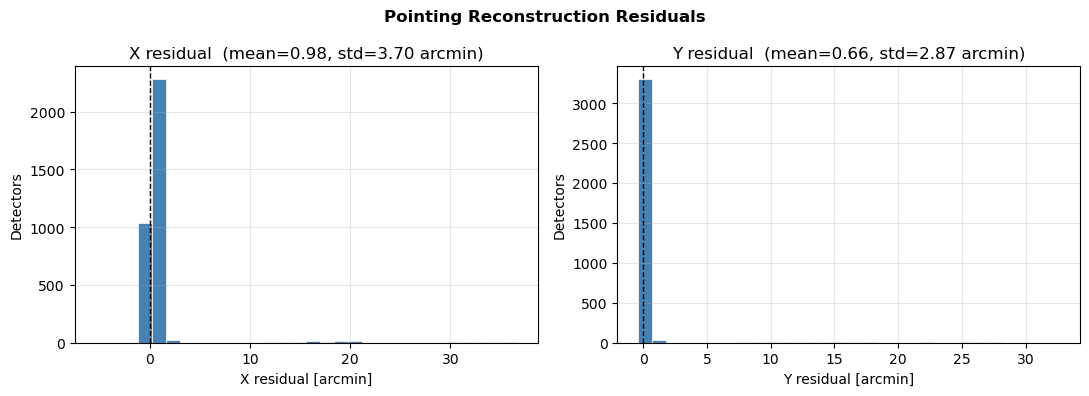

In [14]:
# Residuals: reconstructed - ground truth
dx = recon_x[valid] - nom_x_sel[valid]   # degrees
dy = recon_y[valid] - nom_y_sel[valid]   # degrees

dx_arcmin = dx * 60
dy_arcmin = dy * 60

print(f'Residuals (reconstructed - ground truth):')
print(f'  X: mean={dx_arcmin.mean():.2f}  std={dx_arcmin.std():.2f} arcmin')
print(f'  Y: mean={dy_arcmin.mean():.2f}  std={dy_arcmin.std():.2f} arcmin')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, vals, label in zip(axes, [dx_arcmin, dy_arcmin], ['X residual', 'Y residual']):
    ax.hist(vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel(f'{label} [arcmin]')
    ax.set_ylabel('Detectors')
    ax.set_title(f'{label}  (mean={vals.mean():.2f}, std={vals.std():.2f} arcmin)')
    ax.grid(alpha=0.3)

fig.suptitle('Pointing Reconstruction Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Method A (refined): Gaussian Centroiding

Fit a symmetric 2D Gaussian to the peak region of each detector's map.

In [15]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

def _gauss2d(xy, amp, x0, y0, sigma, bg):
    """Symmetric 2D Gaussian on a flat background."""
    x, y = xy
    return bg + amp * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

GAUSS_HALF_WIN = 3   # +-3 pixels -> 7×7 window

gauss_x     = np.full(n_sel, np.nan)
gauss_y     = np.full(n_sel, np.nan)
gauss_sigma = np.full(n_sel, np.nan)   # fitted beam sigma [arcmin]
gauss_amp   = np.full(n_sel, np.nan)   # fitted amplitude, same units as the map
gauss_bg    = np.full(n_sel, np.nan)   # fitted background level, same units as the map
n_fit_ok = n_fit_fail = 0

for j in range(n_sel):
    if not (np.isfinite(snr[j]) and snr[j] >= SNR_THRESHOLD):
        continue  # skip detectors that failed the argmax SNR cut

    with np.errstate(invalid='ignore', divide='ignore'):
        m = np.where(det_hits[j] > 0, det_data[j] / det_hits[j], np.nan)

    flat_idx = np.nanargmax(m)
    iy, ix   = np.unravel_index(flat_idx, m.shape)

    # Extract window around argmax peak
    iy0 = max(0, iy - GAUSS_HALF_WIN); iy1 = min(ny, iy + GAUSS_HALF_WIN + 1)
    ix0 = max(0, ix - GAUSS_HALF_WIN); ix1 = min(nx, ix + GAUSS_HALF_WIN + 1)
    win = m[iy0:iy1, ix0:ix1]
    if not np.all(np.isfinite(win)):
        n_fit_fail += 1
        continue

    xw = u_centres[ix0:ix1]
    yw = v_centres[iy0:iy1]
    XX, YY = np.meshgrid(xw, yw)
    bg0  = float(np.nanmin(win))
    amp0 = float(np.nanmax(win)) - bg0
    p0   = [amp0, u_centres[ix], v_centres[iy], recon_res_deg, bg0]
    lo   = [0,    xw[0],         yw[0],          recon_res_deg * 0.1, -np.inf]
    hi   = [np.inf, xw[-1],      yw[-1],          recon_res_deg * 8,   np.inf]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(_gauss2d, (XX.ravel(), YY.ravel()),
                                win.ravel(), p0=p0, bounds=(lo, hi), maxfev=2000)
        gauss_x[j]     = popt[1]
        gauss_y[j]     = popt[2]
        gauss_sigma[j] = abs(popt[3]) * 60   # deg → arcmin
        gauss_amp[j]   = popt[0]
        gauss_bg[j]    = popt[4]
        n_fit_ok += 1
    except (RuntimeError, ValueError):
        n_fit_fail += 1

gauss_valid = np.isfinite(gauss_x) & np.isfinite(gauss_y)
print(f'Gaussian fit succeeded: {gauss_valid.sum()} / {n_sel}  '
      f'({n_fit_fail} failed, {n_sel - n_fit_ok - n_fit_fail} skipped by SNR)')
print(f'Fitted beam sigma:: median: {np.nanmedian(gauss_sigma):.3f} arcmin  '
      f'(FWHM ≈ {np.nanmedian(gauss_sigma) * 2.355:.2f} arcmin)')

Gaussian fit succeeded: 2612 / 3426  (814 failed, 0 skipped by SNR)
Fitted beam sigma:: median: 0.447 arcmin  (FWHM ≈ 1.05 arcmin)


Gaussian residuals (2612 detectors):
  X: mean=0.776  std=2.619 arcmin
  Y: mean=0.540  std=2.171 arcmin


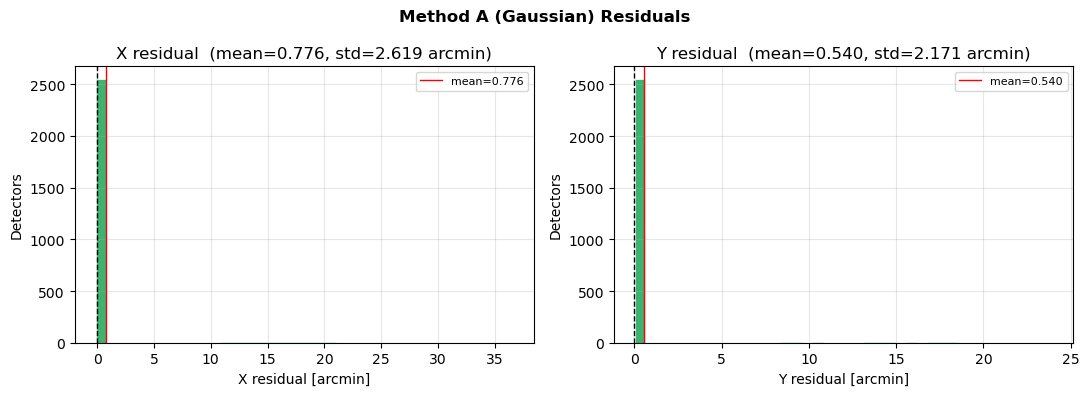

In [16]:
### Gaussian fit: residuals vs ground truth

dx_gau_arcmin = (gauss_x[gauss_valid] - nom_x_sel[gauss_valid]) * 60
dy_gau_arcmin = (gauss_y[gauss_valid] - nom_y_sel[gauss_valid]) * 60

print(f'Gaussian residuals ({gauss_valid.sum()} detectors):')
print(f'  X: mean={dx_gau_arcmin.mean():.3f}  std={dx_gau_arcmin.std():.3f} arcmin')
print(f'  Y: mean={dy_gau_arcmin.mean():.3f}  std={dy_gau_arcmin.std():.3f} arcmin')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, label in zip(axes, [dx_gau_arcmin, dy_gau_arcmin], ['X residual', 'Y residual']):
    ax.hist(vals, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.5)
    ax.axvline(0,           color='k',   linestyle='--', linewidth=1)
    ax.axvline(vals.mean(), color='red', linestyle='-',  linewidth=1, label=f'mean={vals.mean():.3f}')
    ax.set_xlabel(f'{label} [arcmin]')
    ax.set_ylabel('Detectors')
    ax.set_title(f'{label}  (mean={vals.mean():.3f}, std={vals.std():.3f} arcmin)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Method A (Gaussian) Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Verify the Gaussian fits

Residual RMS as a fraction of fitted amplitude, across 2612 fits:
  median: 0.23%   90th pct: 0.68%   max: 3.65%
  (small % -> the fitted Gaussian genuinely describes the data, not just a lucky center)


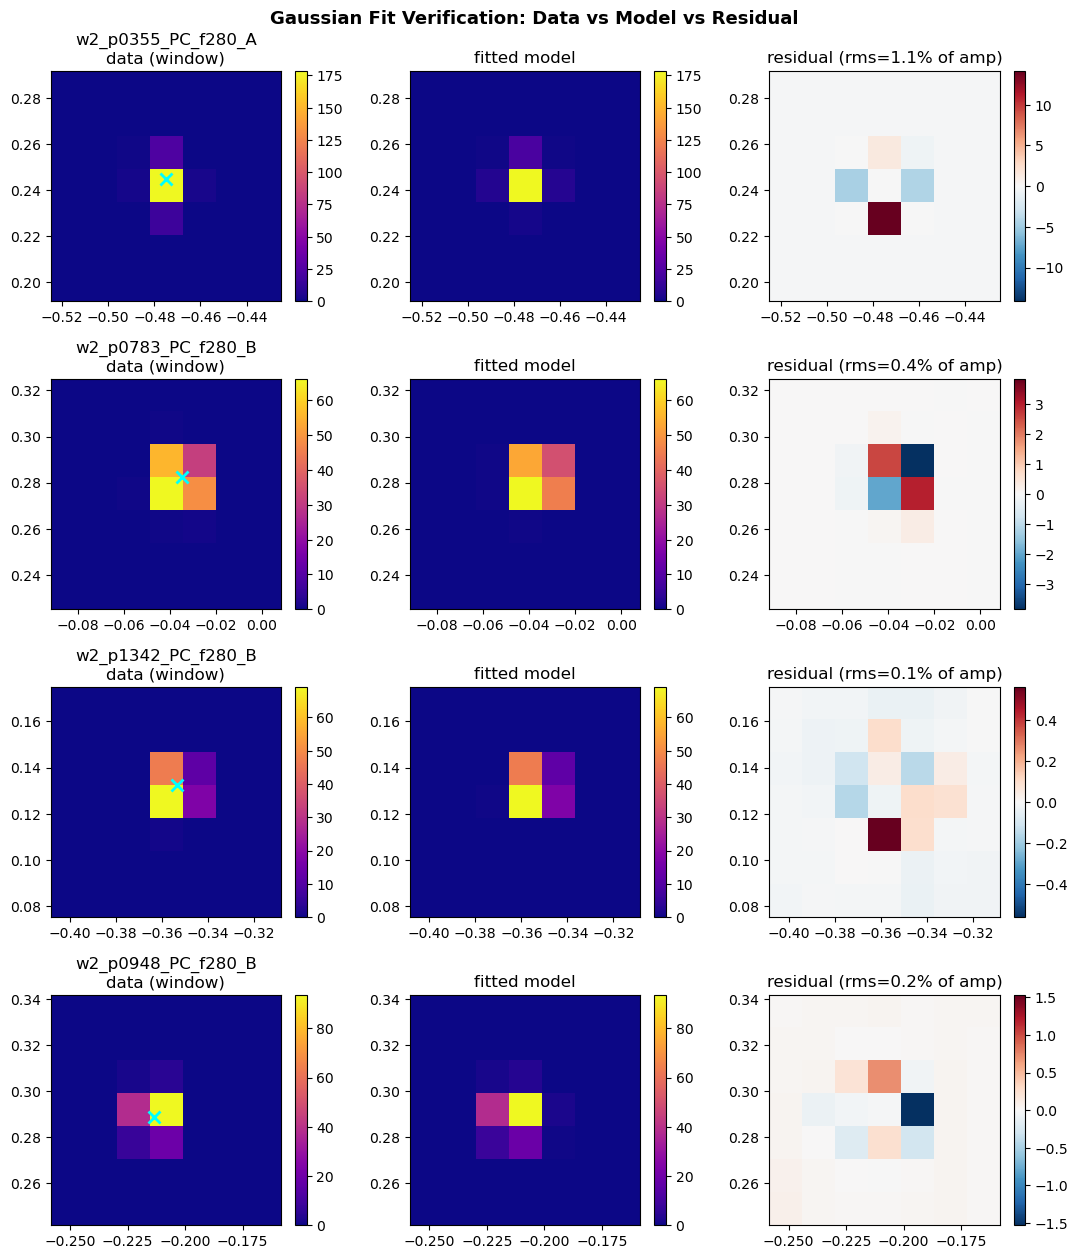

In [17]:
def _fit_window(j):
    """Rebuild the argmax window and its fitted model for detector j (cheap: no recomputation of TOD)."""
    with np.errstate(invalid='ignore', divide='ignore'):
        m = np.where(det_hits[j] > 0, det_data[j] / det_hits[j], np.nan)
    flat_idx = np.nanargmax(m)
    iy, ix   = np.unravel_index(flat_idx, m.shape)
    iy0 = max(0, iy - GAUSS_HALF_WIN); iy1 = min(ny, iy + GAUSS_HALF_WIN + 1)
    ix0 = max(0, ix - GAUSS_HALF_WIN); ix1 = min(nx, ix + GAUSS_HALF_WIN + 1)
    win = m[iy0:iy1, ix0:ix1]
    xw = u_centres[ix0:ix1]
    yw = v_centres[iy0:iy1]
    XX, YY = np.meshgrid(xw, yw)
    model = _gauss2d((XX, YY), gauss_amp[j], gauss_x[j], gauss_y[j], gauss_sigma[j] / 60.0, gauss_bg[j])
    return win, model, xw, yw

resid_frac = np.full(n_sel, np.nan)
for j in np.flatnonzero(gauss_valid):
    win, model, _, _ = _fit_window(j)
    resid_frac[j] = np.sqrt(np.nanmean((win - model) ** 2)) / gauss_amp[j]

print(f'Residual RMS as a fraction of fitted amplitude, across {gauss_valid.sum()} fits:')
print(f'  median: {np.nanmedian(resid_frac)*100:.2f}%   '
      f'90th pct: {np.nanpercentile(resid_frac, 90)*100:.2f}%   '
      f'max: {np.nanmax(resid_frac)*100:.2f}%')
print('  (small % -> the fitted Gaussian genuinely describes the data, not just a lucky center)')

# Visual check
N_CHECK = 4
rng = np.random.default_rng(0)
check_idx = rng.choice(np.flatnonzero(gauss_valid), size=min(N_CHECK, gauss_valid.sum()), replace=False)

fig, axes = plt.subplots(len(check_idx), 3, figsize=(11, 3.2 * len(check_idx)))
if len(check_idx) == 1:
    axes = axes[np.newaxis, :]

for row, j in enumerate(check_idx):
    win, model, xw, yw = _fit_window(j)
    resid = win - model
    vmin, vmax = np.nanmin(win), np.nanmax(win)
    rmax = np.nanmax(np.abs(resid))
    extent = [xw[0], xw[-1], yw[0], yw[-1]]

    ax = axes[row, 0]
    im = ax.imshow(win, origin='lower', extent=extent, vmin=vmin, vmax=vmax, cmap='plasma')
    ax.plot(gauss_x[j], gauss_y[j], marker='x', c='cyan', ms=8, mew=2)
    ax.set_title(f'{selected[j]}\ndata (window)')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[row, 1]
    im = ax.imshow(model, origin='lower', extent=extent, vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title('fitted model')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[row, 2]
    im = ax.imshow(resid, origin='lower', extent=extent, vmin=-rmax, vmax=rmax, cmap='RdBu_r')
    ax.set_title(f'residual (rms={resid_frac[j]*100:.1f}% of amp)')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Gaussian Fit Verification: Data vs Model vs Residual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Targeted refinement: finer resolution around each detector's own peak

The verification above shows the beam (FWHM approx 1.05 arcmin) is barely bigger than the coarse grid's 1 arcmin pixels badly undersampled for a 5-parameter Gaussian fit. Re-gridding the whole 2° focal plane at, say, 0.1 arcmin would need ~5 GB (a 25x jump from the 197 MB estimate earlier) and another ~750s pass, just to resolve peaks that only occupy a tiny fraction of that area.

Instead: reuse each detector's already-known coarse center (`gauss_x`/`gauss_y`) as a guess, and bin a small, finely-sampled window ( $\pm$ 0.05 $\deg$, 0.1 arcmin/pixel) around that per detector, instead of the whole focal plane at fine resolution. Memory stays small (window size is fixed regardless of resolution, not tied to the full field of view) while the beam is now properly resolved. This costs one more streaming pass over the data.

In [18]:
FINE_HALFWIDTH_DEG = 0.05   # +-0.05 deg -> 0.1 deg window per detector
FINE_RES_ARCMIN    = 0.1    # 10x finer than the coarse 1.0 arcmin grid

fine_res_deg = FINE_RES_ARCMIN / 60.0
fine_edges_u, fine_edges_v = make_map_edges(
    ra0_deg=0.0, dec0_deg=0.0,
    xlen_deg=2 * FINE_HALFWIDTH_DEG, ylen_deg=2 * FINE_HALFWIDTH_DEG,
    res_deg=fine_res_deg,
)
fine_ny = len(fine_edges_v) - 1
fine_nx = len(fine_edges_u) - 1
print(f'Fine window: {fine_ny} x {fine_nx} pixels at {FINE_RES_ARCMIN:.2f} arcmin/pixel, '
      f'centered per-detector on its coarse Gaussian fit')

# Only refine detectors that already have a usable coarse center
refine_idx      = np.flatnonzero(gauss_valid)
refine_center_x = gauss_x[refine_idx]
refine_center_y = gauss_y[refine_idx]
n_refine        = len(refine_idx)
refine_j_to_k   = {j: k for k, j in enumerate(refine_idx)}   # j = index into selected/nominal, k = index into fine arrays

print(f'Memory estimate: {n_refine * fine_ny * fine_nx * 4 / 1e6:.0f} MB (data + hits = x2), '
      f'{n_refine} detectors refined')

fine_data = np.zeros((n_refine, fine_ny, fine_nx), dtype=np.float32)
fine_hits = np.zeros((n_refine, fine_ny, fine_nx), dtype=np.float32)

n_chunks = 0
t0 = time.perf_counter()
kid_to_i_fine = None

for chunk in iter_g3_chunks(cfg):
    if kid_to_i_fine is None:
        kid_to_i_fine = {k: i for i, k in enumerate(chunk.kids)}

    boresight_r = Rotation.from_quat(chunk.boresight_q)
    src_fp = boresight_r.inv().apply(src_vec)
    du = np.degrees(np.arctan2(src_fp[:, 0], src_fp[:, 2]))
    dv = np.degrees(np.arctan2(src_fp[:, 1], src_fp[:, 2]))

    baseline = np.median(chunk.signal, axis=0)
    sig = chunk.signal - baseline[np.newaxis, :]

    for j in refine_idx:
        kid = selected[j]
        if kid not in kid_to_i_fine:
            continue
        i = kid_to_i_fine[kid]
        k = refine_j_to_k[j]
        # shift so this detector's own coarse center sits at the origin of the shared fine grid
        du_shift = du - refine_center_x[k]
        dv_shift = dv - refine_center_y[k]
        d, h = bin_detector(sig[:, i], du_shift, dv_shift, fine_edges_u, fine_edges_v)
        fine_data[k] += d.astype(np.float32)
        fine_hits[k] += h.astype(np.float32)

    n_chunks += 1
    if n_chunks % 10 == 0:
        print(f'  chunk {n_chunks}...', end='\r')

print(f'\nDone: {n_chunks} chunks in {time.perf_counter() - t0:.1f}s')

Fine window: 60 x 60 pixels at 0.10 arcmin/pixel, centered per-detector on its coarse Gaussian fit
Memory estimate: 38 MB (data + hits = x2), 2612 detectors refined
  chunk 1260...
Done: 1260 chunks in 413.7s


In [19]:
fine_u_centres = 0.5 * (fine_edges_u[:-1] + fine_edges_u[1:])
fine_v_centres = 0.5 * (fine_edges_v[:-1] + fine_edges_v[1:])

FINE_GAUSS_HALF_WIN = 5   # +-5 pixels at 0.1 arcmin/pixel -> ~1 arcmin window, well-sampled beam
MIN_FINITE_PIX = 10       # need at least this many sampled pixels to fit 5 free parameters

fine_x     = np.full(n_sel, np.nan)
fine_y     = np.full(n_sel, np.nan)
fine_sigma = np.full(n_sel, np.nan)
fine_amp   = np.full(n_sel, np.nan)   # fitted amplitude, same units as the map
fine_bg    = np.full(n_sel, np.nan)   # fitted background level, same units as the map
n_fine_ok = n_fine_fail = 0

for k, j in enumerate(refine_idx):
    with np.errstate(invalid='ignore', divide='ignore'):
        m = np.where(fine_hits[k] > 0, fine_data[k] / fine_hits[k], np.nan)
    if not np.any(np.isfinite(m)):
        n_fine_fail += 1
        continue

    flat_idx = np.nanargmax(m)
    iy, ix   = np.unravel_index(flat_idx, m.shape)
    iy0 = max(0, iy - FINE_GAUSS_HALF_WIN); iy1 = min(fine_ny, iy + FINE_GAUSS_HALF_WIN + 1)
    ix0 = max(0, ix - FINE_GAUSS_HALF_WIN); ix1 = min(fine_nx, ix + FINE_GAUSS_HALF_WIN + 1)
    win = m[iy0:iy1, ix0:ix1]

    # Sparse, scan-sampled data at this resolution rarely fills the whole window --
    # fit using only the actually-sampled (finite) pixels, not a dense rectangular grid.
    finite_mask = np.isfinite(win)
    if finite_mask.sum() < MIN_FINITE_PIX:
        n_fine_fail += 1
        continue

    xw = fine_u_centres[ix0:ix1]
    yw = fine_v_centres[iy0:iy1]
    XX, YY = np.meshgrid(xw, yw)
    win_pts = win[finite_mask]
    xx_pts  = XX[finite_mask]
    yy_pts  = YY[finite_mask]

    bg0  = float(np.nanmin(win_pts))
    amp0 = float(np.nanmax(win_pts)) - bg0
    p0   = [amp0, fine_u_centres[ix], fine_v_centres[iy], fine_res_deg, bg0]
    lo   = [0,    xw[0],              yw[0],               fine_res_deg * 0.1, -np.inf]
    hi   = [np.inf, xw[-1],           yw[-1],               fine_res_deg * 8,   np.inf]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(_gauss2d, (xx_pts, yy_pts),
                                win_pts, p0=p0, bounds=(lo, hi), maxfev=2000)
        # grid was centered on the coarse guess -- shift back to add it in
        fine_x[j]     = popt[1] + refine_center_x[k]
        fine_y[j]     = popt[2] + refine_center_y[k]
        fine_sigma[j] = abs(popt[3]) * 60
        fine_amp[j]   = popt[0]
        fine_bg[j]    = popt[4]
        n_fine_ok += 1
    except (RuntimeError, ValueError):
        n_fine_fail += 1

fine_valid = np.isfinite(fine_x) & np.isfinite(fine_y)
print(f'Fine-grid fit succeeded: {fine_valid.sum()} / {n_refine} refined '
      f'({n_fine_fail} failed)')
print(f'Fine-fitted beam sigma : median: {np.nanmedian(fine_sigma):.3f} arcmin  '
      f'(FWHM ≈ {np.nanmedian(fine_sigma) * 2.355:.2f} arcmin)')

dx_fine = (fine_x[fine_valid] - nom_x_sel[fine_valid]) * 60
dy_fine = (fine_y[fine_valid] - nom_y_sel[fine_valid]) * 60
print(f'\nFine-grid residuals ({fine_valid.sum()} detectors):')
print(f'  X: mean={dx_fine.mean():.3f}  std={dx_fine.std():.3f} arcmin')
print(f'  Y: mean={dy_fine.mean():.3f}  std={dy_fine.std():.3f} arcmin')

both = gauss_valid & fine_valid
dx_coarse_c = (gauss_x[both] - nom_x_sel[both]) * 60
dy_coarse_c = (gauss_y[both] - nom_y_sel[both]) * 60
dx_fine_c   = (fine_x[both]  - nom_x_sel[both]) * 60
dy_fine_c   = (fine_y[both]  - nom_y_sel[both]) * 60
print(f'\nSame {both.sum()} detectors, coarse vs fine:')
print(f'  coarse (1.0 arcmin/px): X std={dx_coarse_c.std():.3f}  Y std={dy_coarse_c.std():.3f} arcmin')
print(f'  fine   (0.1 arcmin/px): X std={dx_fine_c.std():.3f}  Y std={dy_fine_c.std():.3f} arcmin')


Fine-grid fit succeeded: 2581 / 2612 refined (31 failed)
Fine-fitted beam sigma : median: 0.367 arcmin  (FWHM ≈ 0.86 arcmin)

Fine-grid residuals (2581 detectors):
  X: mean=0.780  std=2.680 arcmin
  Y: mean=0.534  std=2.131 arcmin

Same 2581 detectors, coarse vs fine:
  coarse (1.0 arcmin/px): X std=2.634  Y std=2.184 arcmin
  fine   (0.1 arcmin/px): X std=2.680  Y std=2.131 arcmin


### Fine-grid results: Ground truth vs reconstructed

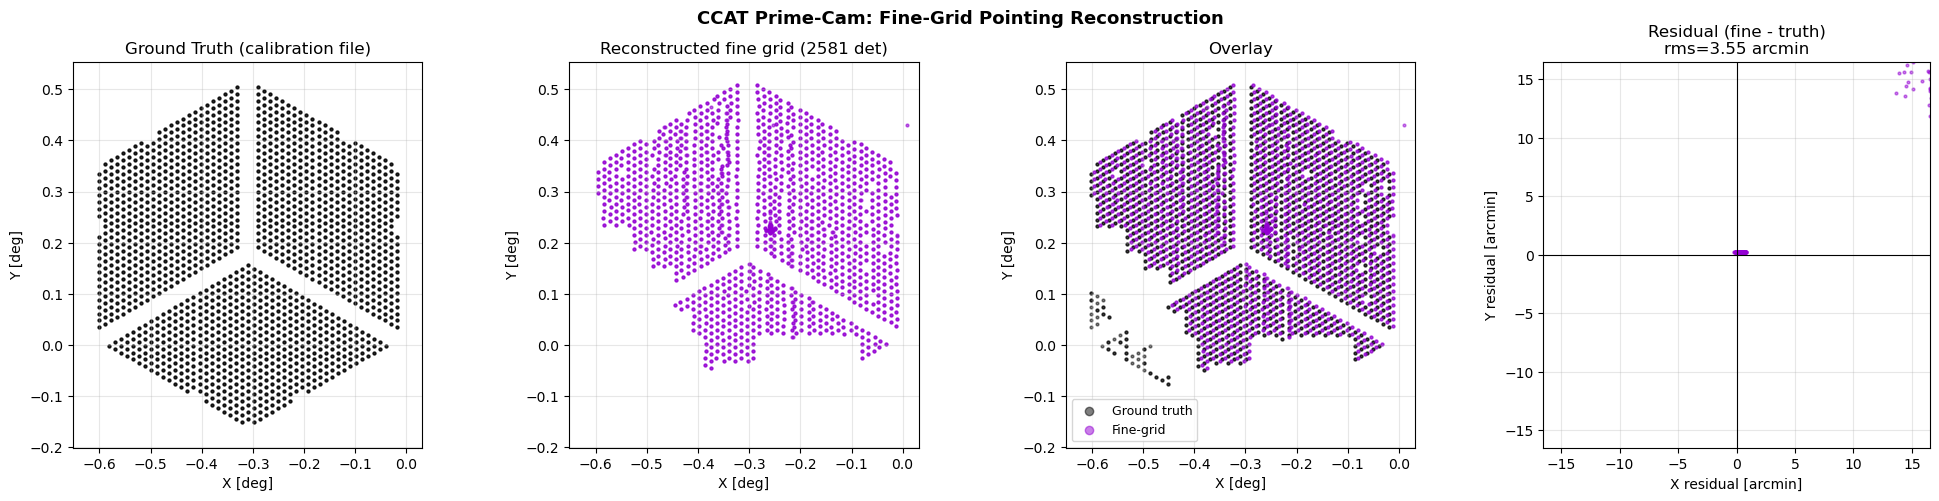

In [20]:
margin = 0.05   # deg padding around ground truth extent
xlim = (nom_x_sel.min() - margin, nom_x_sel.max() + margin)
ylim = (nom_y_sel.min() - margin, nom_y_sel.max() + margin)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.scatter(nom_x_sel, nom_y_sel, s=4, c='k', alpha=0.6)
ax.set_title('Ground Truth (calibration file)')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(fine_x[fine_valid], fine_y[fine_valid], s=4, c='darkviolet', alpha=0.6)
ax.set_title(f'Reconstructed fine grid ({fine_valid.sum()} det)')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(nom_x_sel[fine_valid], nom_y_sel[fine_valid], s=4, c='k', alpha=0.5, label='Ground truth')
ax.scatter(fine_x[fine_valid],    fine_y[fine_valid],    s=4, c='darkviolet', alpha=0.5, label='Fine-grid')
ax.set_title('Overlay')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.legend(markerscale=3, fontsize=9)

# Residual: reuse dx_fine/dy_fine (already fine_x/fine_y - nom_x_sel/nom_y_sel, in arcmin
# same sign convention as every other residual in this notebook). Needs its own, much
# smaller axis limits residuals are ~arcmin scale, not the full focal-plane extent.
ax = axes[3]
ax.scatter(dx_fine, dy_fine, s=4, c='darkviolet', alpha=0.5)
ax.axhline(0, color='k', linewidth=0.8)
ax.axvline(0, color='k', linewidth=0.8)
rlim = max(np.percentile(np.abs(np.concatenate([dx_fine, dy_fine])), 99), 0.1)
ax.set_xlim(-rlim, rlim); ax.set_ylim(-rlim, rlim)
ax.set_title(f'Residual (fine - truth)\nrms={np.sqrt((dx_fine**2+dy_fine**2).mean()):.2f} arcmin')
ax.set_xlabel('X residual [arcmin]'); ax.set_ylabel('Y residual [arcmin]')
ax.set_aspect('equal'); ax.grid(alpha=0.3)

fig.suptitle('CCAT Prime-Cam: Fine-Grid Pointing Reconstruction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

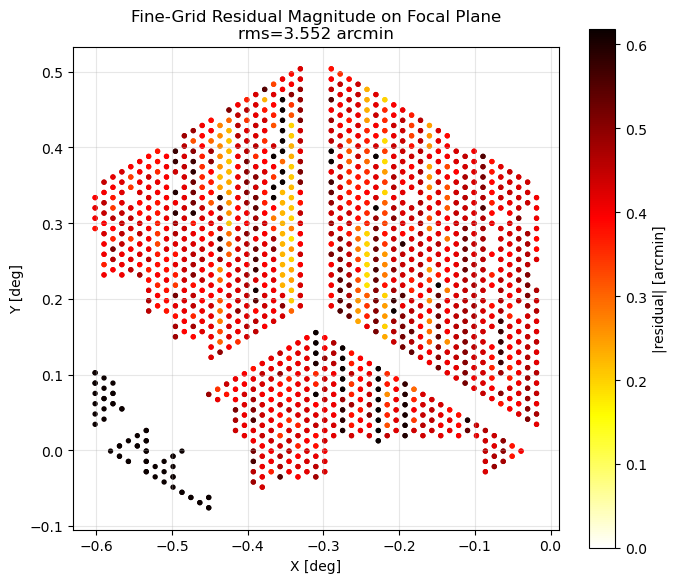

In [21]:
# Where on the focal plane are the errors largest?
fig, ax = plt.subplots(figsize=(7, 6))
err_fine = np.sqrt(dx_fine**2 + dy_fine**2)
vmax = np.percentile(err_fine, 95)
sc = ax.scatter(nom_x_sel[fine_valid], nom_y_sel[fine_valid], c=err_fine, cmap='hot_r', s=8,
                vmin=0, vmax=vmax)
plt.colorbar(sc, ax=ax, label='|residual| [arcmin]')
ax.set_title(f'Fine-Grid Residual Magnitude on Focal Plane\n'
             f'rms={np.sqrt((dx_fine**2 + dy_fine**2).mean()):.3f} arcmin')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

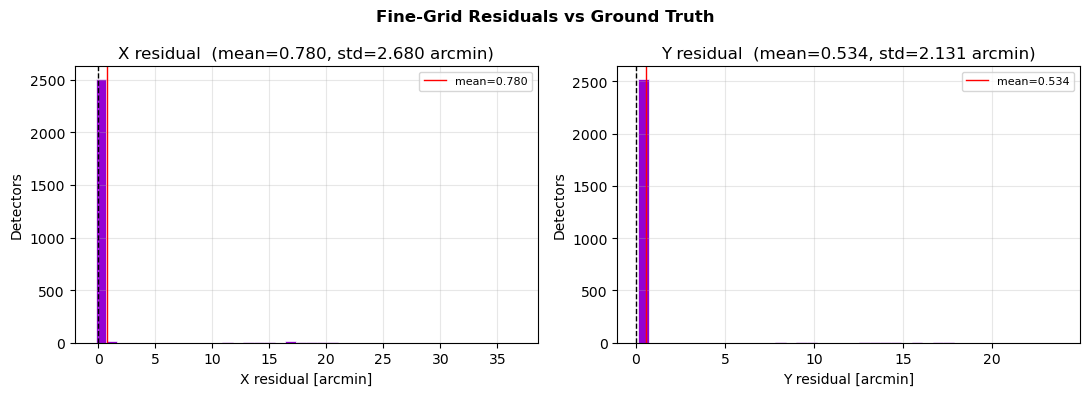

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, label in zip(axes, [dx_fine, dy_fine], ['X residual', 'Y residual']):
    ax.hist(vals, bins=40, color='darkviolet', edgecolor='white', linewidth=0.5)
    ax.axvline(0,           color='k',   linestyle='--', linewidth=1)
    ax.axvline(vals.mean(), color='red', linestyle='-',  linewidth=1, label=f'mean={vals.mean():.3f}')
    ax.set_xlabel(f'{label} [arcmin]')
    ax.set_ylabel('Detectors')
    ax.set_title(f'{label}  (mean={vals.mean():.3f}, std={vals.std():.3f} arcmin)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Fine-Grid Residuals vs Ground Truth', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Verify the fine-grid fits

Same idea as the coarse-fit verification above, adapted for sparse data: this window is *supposed* to have gaps (blank pixels below are unsampled, not zero signal) since it fits used only the actually-sampled points. The residual metric below is computed only at those sampled points, and the "model" panel is evaluated densely across the whole window so you can see the smooth curve the sparse points were actually fit to.

Residual RMS as a fraction of fitted amplitude, across 2581 fine fits:
  median: 3.24%   90th pct: 6.64%   max: 89.25%


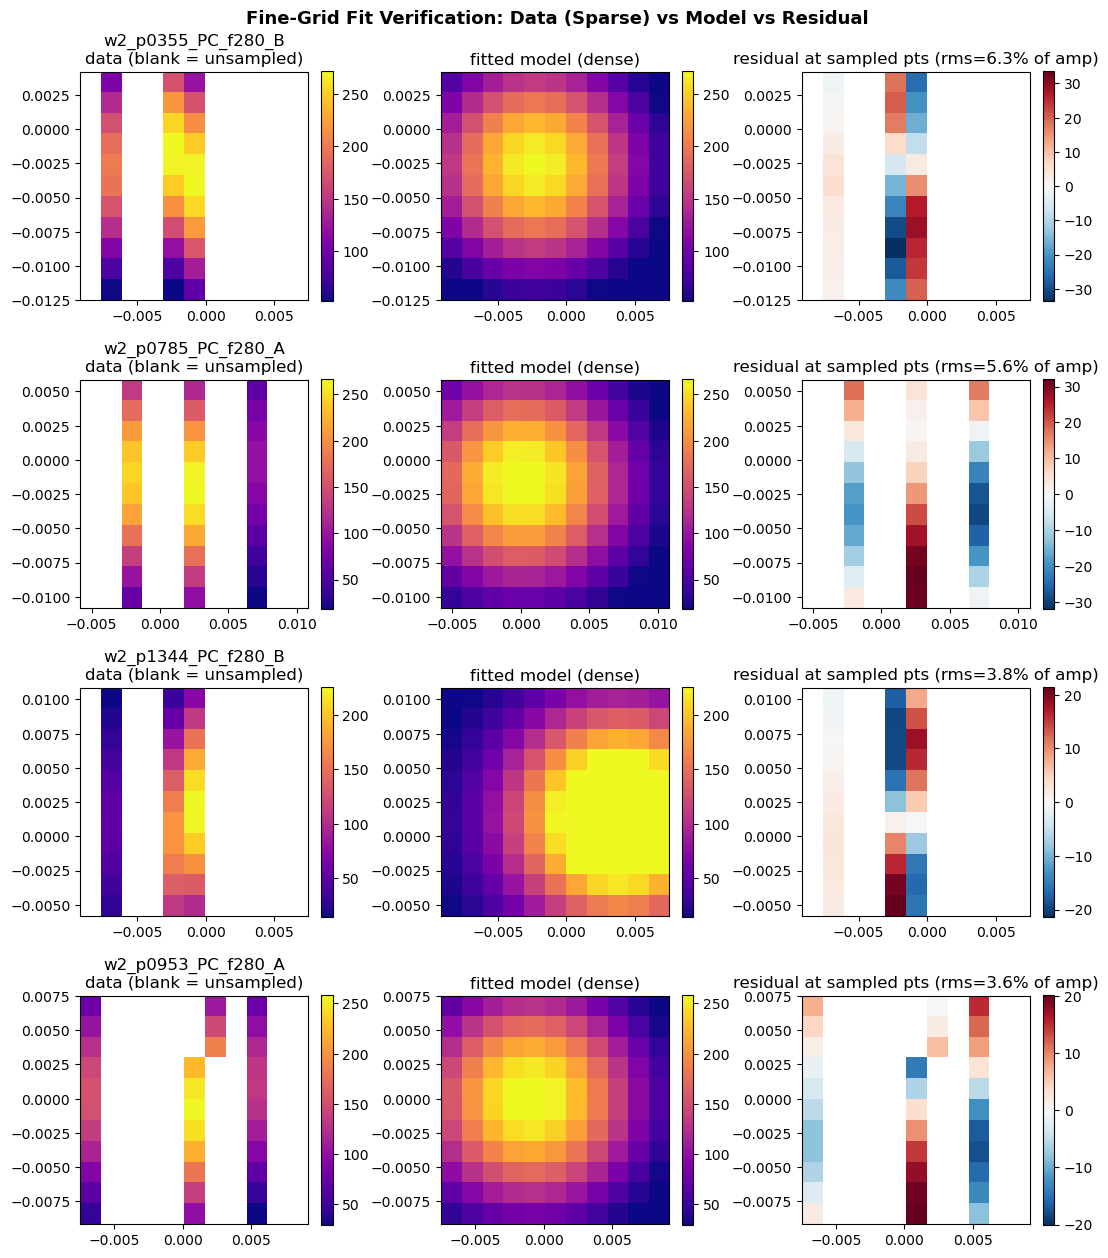

In [23]:
def _fine_fit_window(j):
    """Rebuild the fine window and its fitted model for detector j (cheap: reuses fine_data/fine_hits)."""
    k = refine_j_to_k[j]
    with np.errstate(invalid='ignore', divide='ignore'):
        m = np.where(fine_hits[k] > 0, fine_data[k] / fine_hits[k], np.nan)
    flat_idx = np.nanargmax(m)
    iy, ix   = np.unravel_index(flat_idx, m.shape)
    iy0 = max(0, iy - FINE_GAUSS_HALF_WIN); iy1 = min(fine_ny, iy + FINE_GAUSS_HALF_WIN + 1)
    ix0 = max(0, ix - FINE_GAUSS_HALF_WIN); ix1 = min(fine_nx, ix + FINE_GAUSS_HALF_WIN + 1)
    win = m[iy0:iy1, ix0:ix1]
    xw = fine_u_centres[ix0:ix1]
    yw = fine_v_centres[iy0:iy1]
    XX, YY = np.meshgrid(xw, yw)
    # fine_x/fine_y are already shifted back to absolute coords undo that to match
    # the local (window-relative) frame the fit actually ran in.
    local_x0 = fine_x[j] - refine_center_x[k]
    local_y0 = fine_y[j] - refine_center_y[k]
    model = _gauss2d((XX, YY), fine_amp[j], local_x0, local_y0, fine_sigma[j] / 60.0, fine_bg[j])
    return win, model, xw, yw

fine_resid_frac = np.full(n_sel, np.nan)
for j in np.flatnonzero(fine_valid):
    win, model, _, _ = _fine_fit_window(j)
    mask = np.isfinite(win)
    fine_resid_frac[j] = np.sqrt(np.nanmean((win[mask] - model[mask]) ** 2)) / fine_amp[j]

print(f'Residual RMS as a fraction of fitted amplitude, across {fine_valid.sum()} fine fits:')
print(f'  median: {np.nanmedian(fine_resid_frac)*100:.2f}%   '
      f'90th pct: {np.nanpercentile(fine_resid_frac, 90)*100:.2f}%   '
      f'max: {np.nanmax(fine_resid_frac)*100:.2f}%')

N_CHECK = 4
rng = np.random.default_rng(0)
check_idx = rng.choice(np.flatnonzero(fine_valid), size=min(N_CHECK, fine_valid.sum()), replace=False)

fig, axes = plt.subplots(len(check_idx), 3, figsize=(11, 3.2 * len(check_idx)))
if len(check_idx) == 1:
    axes = axes[np.newaxis, :]

for row, j in enumerate(check_idx):
    win, model, xw, yw = _fine_fit_window(j)
    mask = np.isfinite(win)
    resid = np.where(mask, win - model, np.nan)   # only meaningful at sampled points
    vmin, vmax = np.nanmin(win), np.nanmax(win)
    rmax = np.nanmax(np.abs(resid[mask])) if mask.any() else 1.0
    extent = [xw[0], xw[-1], yw[0], yw[-1]]

    ax = axes[row, 0]
    im = ax.imshow(win, origin='lower', extent=extent, vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title(f'{selected[j]}\ndata (blank = unsampled)')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[row, 1]
    im = ax.imshow(model, origin='lower', extent=extent, vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title('fitted model (dense)')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[row, 2]
    im = ax.imshow(resid, origin='lower', extent=extent, vmin=-rmax, vmax=rmax, cmap='RdBu_r')
    ax.set_title(f'residual at sampled pts (rms={fine_resid_frac[j]*100:.1f}% of amp)')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Fine-Grid Fit Verification: Data (Sparse) vs Model vs Residual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Method A: Argmax vs Gaussian (coarse) vs Gaussian (fine)

Common valid detectors: 2581 / 3426

Method                   X mean   X std   Y mean   Y std  (arcmin)
------------------------------------------------------------
A  argmax (coarse)        0.811   2.693    0.538   2.128  rms=3.568
A  Gaussian (coarse)      0.781   2.634    0.544   2.184  rms=3.551
A  Gaussian (fine)        0.780   2.680    0.534   2.131  rms=3.552


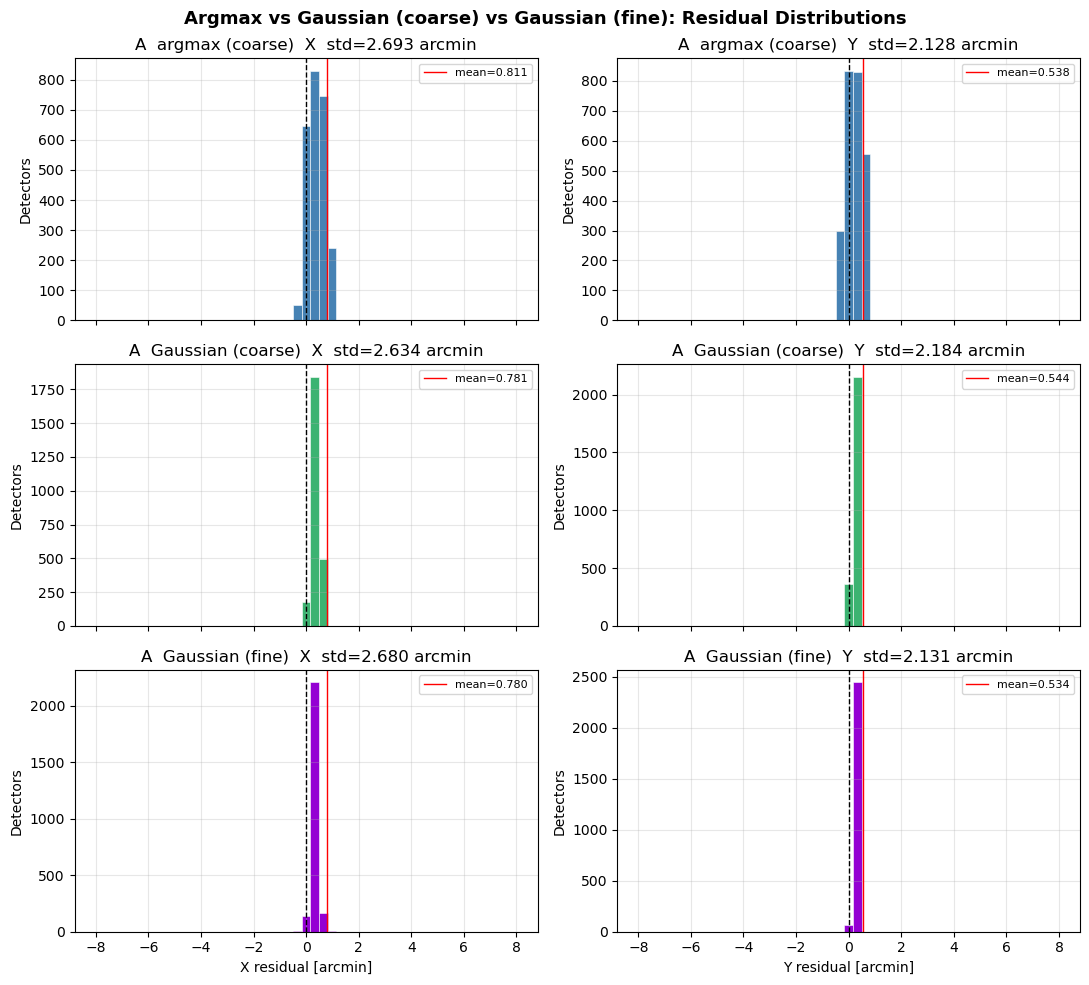

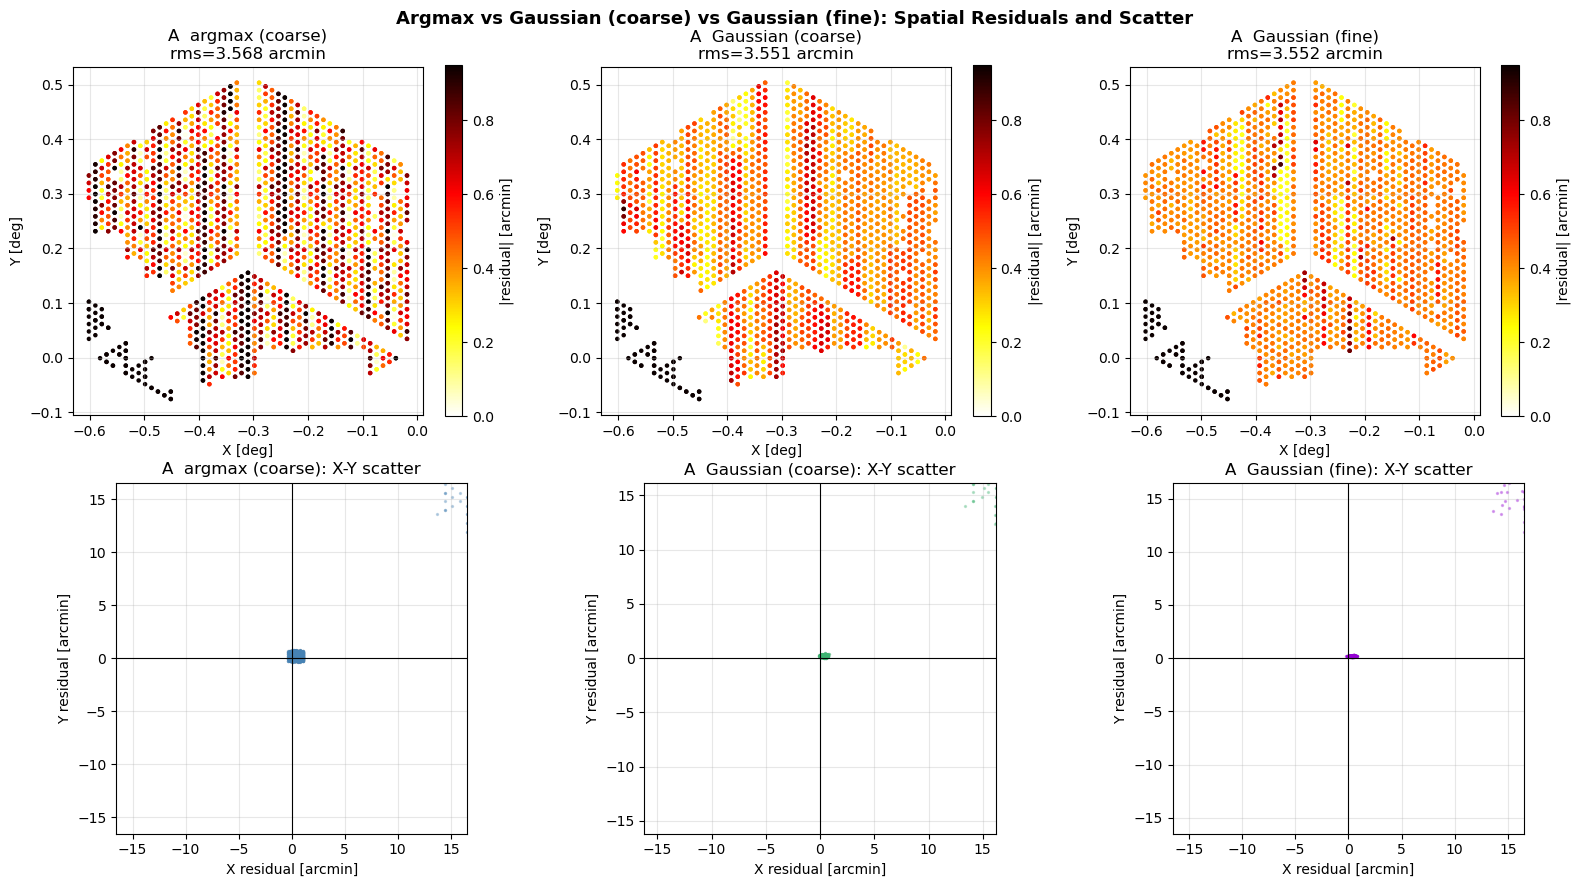

In [24]:
# Detectors valid in all three
all_valid_3 = valid & gauss_valid & fine_valid

nom_x_3 = nom_x_sel[all_valid_3]
nom_y_3 = nom_y_sel[all_valid_3]

dx_arg3 = (recon_x[all_valid_3] - nom_x_3) * 60   # arcmin
dy_arg3 = (recon_y[all_valid_3] - nom_y_3) * 60
dx_gau3 = (gauss_x[all_valid_3] - nom_x_3) * 60
dy_gau3 = (gauss_y[all_valid_3] - nom_y_3) * 60
dx_fin3 = (fine_x[all_valid_3]  - nom_x_3) * 60
dy_fin3 = (fine_y[all_valid_3]  - nom_y_3) * 60

methods3 = [
    ('A  argmax (coarse)',   dx_arg3, dy_arg3, 'steelblue'),
    ('A  Gaussian (coarse)', dx_gau3, dy_gau3, 'mediumseagreen'),
    ('A  Gaussian (fine)',   dx_fin3, dy_fin3, 'darkviolet'),
]

print(f'Common valid detectors: {all_valid_3.sum()} / {n_sel}\n')
print(f'{"Method":<22} {"X mean":>8} {"X std":>7} {"Y mean":>8} {"Y std":>7}  (arcmin)')
print('-' * 60)
for label, dx, dy, _ in methods3:
    rms = np.sqrt((dx**2 + dy**2).mean())
    print(f'{label:<22} {dx.mean():>8.3f} {dx.std():>7.3f} {dy.mean():>8.3f} {dy.std():>7.3f}  rms={rms:.3f}')

# Plot 1: residual histograms, all three methods
fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True, sharey=False)
bins = np.linspace(-8, 8, 50)
for row, (label, dx, dy, color) in enumerate(methods3):
    for col, (vals, axis_label) in enumerate([(dx, 'X'), (dy, 'Y')]):
        ax = axes[row, col]
        ax.hist(vals, bins=bins, color=color, edgecolor='white', linewidth=0.4)
        ax.axvline(0,           color='k',   linestyle='--', linewidth=1)
        ax.axvline(vals.mean(), color='red', linestyle='-',  linewidth=1,
                   label=f'mean={vals.mean():.3f}')
        ax.set_ylabel('Detectors')
        ax.set_title(f'{label}  {axis_label}  std={vals.std():.3f} arcmin')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
axes[-1, 0].set_xlabel('X residual [arcmin]')
axes[-1, 1].set_xlabel('Y residual [arcmin]')
fig.suptitle('Argmax vs Gaussian (coarse) vs Gaussian (fine): Residual Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: focal plane residual maps + scatter
vmax3 = np.percentile(
    np.concatenate([np.sqrt(dx_arg3**2 + dy_arg3**2),
                    np.sqrt(dx_gau3**2 + dy_gau3**2),
                    np.sqrt(dx_fin3**2 + dy_fin3**2)]), 95)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (label, dx, dy, color) in enumerate(methods3):
    err = np.sqrt(dx**2 + dy**2)

    ax = axes[0, col]
    sc = ax.scatter(nom_x_3, nom_y_3, c=err, cmap='hot_r', s=5, vmin=0, vmax=vmax3)
    plt.colorbar(sc, ax=ax, label='|residual| [arcmin]')
    ax.set_title(f'{label}\nrms={np.sqrt((dx**2 + dy**2).mean()):.3f} arcmin')
    ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)

    ax = axes[1, col]
    ax.scatter(dx, dy, s=2, alpha=0.3, color=color)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel('X residual [arcmin]'); ax.set_ylabel('Y residual [arcmin]')
    ax.set_title(f'{label}: X-Y scatter')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    lim = max(np.percentile(np.abs(np.concatenate([dx, dy])), 99), 0.1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

fig.suptitle('Argmax vs Gaussian (coarse) vs Gaussian (fine): Spatial Residuals and Scatter',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Method B, Time-based (peak timestamp)

For each detector, find the time sample where its signal peaks. At that moment the boresight was displaced from Jupiter by exactly that detector's focal plane offset:

Benefit of no maps, no pixel quantization, naturally sub-arcminute, fully vectorizable, fast.  
But, single-sample argmax is noisy & a noise spike can dominate. In practice, would smooth the TOD or use a weighted mean around the peak.

In [25]:
import time

peak_val    = np.full(n_sel, -np.inf, dtype=np.float64)
peak_ra_b   = np.zeros(n_sel)
peak_dec_b  = np.zeros(n_sel)
peak_bq     = np.zeros((n_sel, 4))   # boresight quaternion (x,y,z,w) at peak time

n_chunks = 0
t0 = time.perf_counter()
kid_to_i_tb = None
pipe_cfg = cfg['pipeline']

for chunk in iter_g3_chunks(cfg):
    if kid_to_i_tb is None:
        kid_to_i_tb = {k: i for i, k in enumerate(chunk.kids)}

    j_arr = np.array([j for j, k in enumerate(selected) if k in kid_to_i_tb])
    i_arr = np.array([kid_to_i_tb[selected[j]] for j in j_arr])
    if len(j_arr) == 0:
        continue

    baseline = np.median(chunk.signal, axis=0)
    sig = chunk.signal - baseline[np.newaxis, :]
    sig = clean_tod(sig, chunk.sample_rate,
                    cosmic_rays=pipe_cfg['clean_cosmic_rays'],
                    highpass_hz=pipe_cfg['highpass_cutoff_hz'])

    sig_sel = sig[:, i_arr]
    t_max   = sig_sel.argmax(axis=0)
    max_val = sig_sel.max(axis=0)

    update = max_val > peak_val[j_arr]
    j_upd  = j_arr[update]
    t_upd  = t_max[update]
    peak_val[j_upd]   = max_val[update]
    peak_ra_b[j_upd]  = chunk.ra_bore[t_upd]
    peak_dec_b[j_upd] = chunk.dec_bore[t_upd]
    peak_bq[j_upd]    = chunk.boresight_q[t_upd]   # quaternion at peak sample

    n_chunks += 1
    if n_chunks % 10 == 0:
        print(f'  chunk {n_chunks}...', end='\r')

print(f'\nDone: {n_chunks} chunks in {time.perf_counter() - t0:.1f}s')
print(f'Detectors with signal: {(peak_val > -np.inf).sum()} / {n_sel}')

  chunk 1260...
Done: 1260 chunks in 358.0s
Detectors with signal: 3426 / 3426


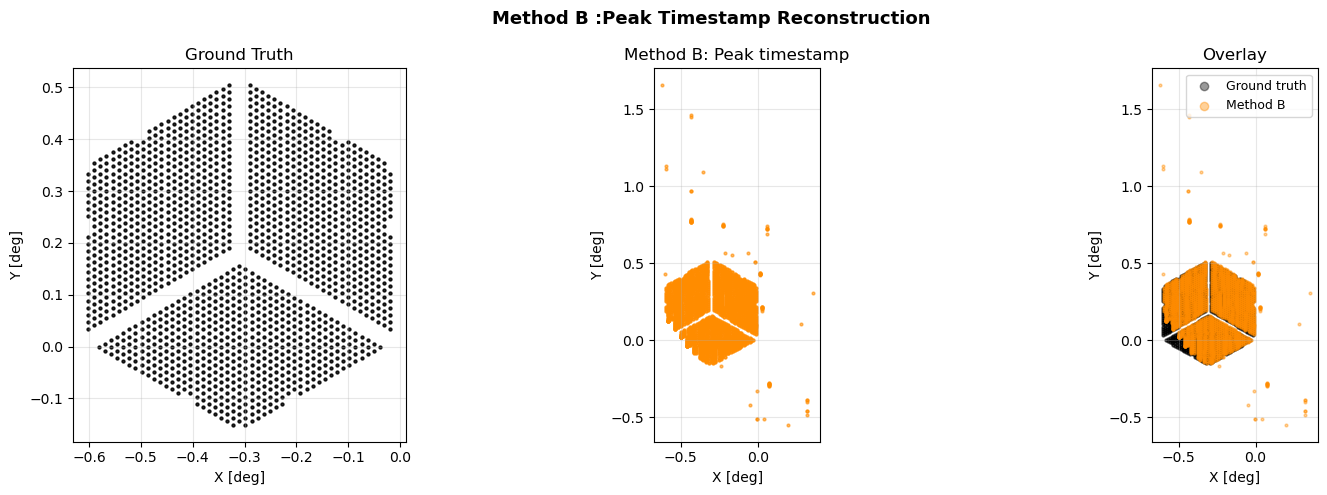

Method B residuals (3426 detectors):
  X: mean=1.09  std=4.93 arcmin
  Y: mean=0.74  std=5.92 arcmin


In [26]:
### Method B results

# Jupiter's unit vector  same as Method A
src_vec = np.array([
    np.cos(np.radians(DEC_SRC)) * np.cos(np.radians(RA_SRC)),
    np.cos(np.radians(DEC_SRC)) * np.sin(np.radians(RA_SRC)),
    np.sin(np.radians(DEC_SRC))
])

tb_valid = peak_val > -np.inf

# Project Jupiter into the focal plane frame using the boresight quaternion AT peak time.

r_peak  = Rotation.from_quat(peak_bq[tb_valid])         # one rotation per detector
src_fp  = r_peak.inv().apply(src_vec)                    # (n_valid, 3)
time_x  = np.full(n_sel, np.nan)
time_y  = np.full(n_sel, np.nan)
time_x[tb_valid] = np.degrees(np.arctan2(src_fp[:, 0], src_fp[:, 2]))
time_y[tb_valid] = np.degrees(np.arctan2(src_fp[:, 1], src_fp[:, 2]))

nom_x_sel = np.array([nominal[k][0] for k in selected])
nom_y_sel = np.array([nominal[k][1] for k in selected])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(nom_x_sel, nom_y_sel, s=4, c='k', alpha=0.6)
ax.set_title('Ground Truth'); ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(time_x[tb_valid], time_y[tb_valid], s=4, c='darkorange', alpha=0.6)
ax.set_title('Method B: Peak timestamp'); ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c='k', alpha=0.4, label='Ground truth')
ax.scatter(time_x[tb_valid],    time_y[tb_valid],    s=4, c='darkorange', alpha=0.4, label='Method B')
ax.set_title('Overlay'); ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(markerscale=3, fontsize=9)

fig.suptitle('Method B :Peak Timestamp Reconstruction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

dx_tb = (time_x[tb_valid] - nom_x_sel[tb_valid]) * 60
dy_tb = (time_y[tb_valid] - nom_y_sel[tb_valid]) * 60
print(f'Method B residuals ({tb_valid.sum()} detectors):')
print(f'  X: mean={dx_tb.mean():.2f}  std={dx_tb.std():.2f} arcmin')
print(f'  Y: mean={dy_tb.mean():.2f}  std={dy_tb.std():.2f} arcmin')

## JUSTIFICATION FOR THE PROJECTION

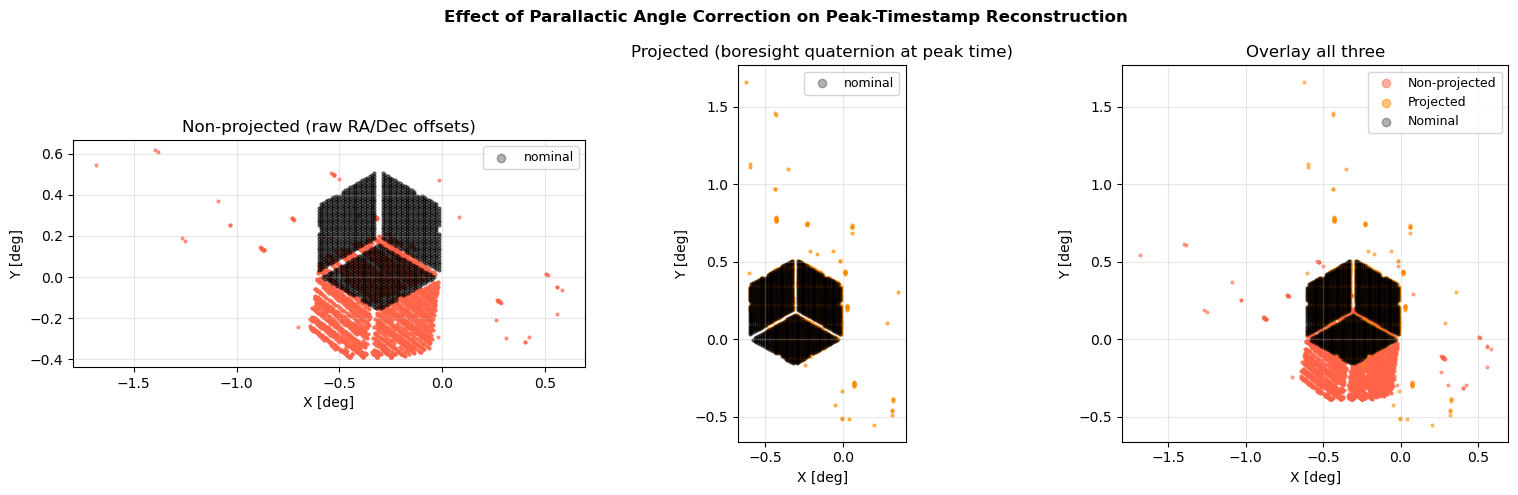

Non-projected residuals  X: mean=-1.11 std=9.86 arcmin  Y: mean=-17.64 std=9.56 arcmin
Projected residuals    X: mean=1.09 std=4.93 arcmin  Y: mean=0.74 std=5.92 arcmin


In [27]:
### Projected vs non-projected comparison

# Non-projected: raw RA/Dec offsets at peak time, no coordinate frame correction.
# Fails because different detectors peak at different times -> different parallactic angles
# Each detector's offset is in a different rotated frame.
cos_dec = np.cos(np.radians(DEC_SRC))
raw_x = np.full(n_sel, np.nan)
raw_y = np.full(n_sel, np.nan)
raw_x[tb_valid] = (RA_SRC - peak_ra_b[tb_valid]) * cos_dec
raw_y[tb_valid] =  DEC_SRC - peak_dec_b[tb_valid]

# Projected: time_x, time_y already computed above using boresight quaternion at peak time

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(raw_x[tb_valid], raw_y[tb_valid], s=4, c='tomato', alpha=0.6)
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c='k', alpha=0.3, label='nominal')
ax.set_title('Non-projected (raw RA/Dec offsets)')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(markerscale=3, fontsize=9)

ax = axes[1]
ax.scatter(time_x[tb_valid], time_y[tb_valid], s=4, c='darkorange', alpha=0.6)
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c='k', alpha=0.3, label='nominal')
ax.set_title('Projected (boresight quaternion at peak time)')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(markerscale=3, fontsize=9)

ax = axes[2]
ax.scatter(raw_x[tb_valid],  raw_y[tb_valid],  s=4, c='tomato',     alpha=0.5, label='Non-projected')
ax.scatter(time_x[tb_valid], time_y[tb_valid], s=4, c='darkorange', alpha=0.5, label='Projected')
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c='k', alpha=0.3, label='Nominal')
ax.set_title('Overlay all three')
ax.set_xlabel('X [deg]'); ax.set_ylabel('Y [deg]')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(markerscale=3, fontsize=9)

fig.suptitle('Effect of Parallactic Angle Correction on Peak-Timestamp Reconstruction',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

dx_raw = (raw_x[tb_valid] - nom_x_sel[tb_valid]) * 60
dy_raw = (raw_y[tb_valid] - nom_y_sel[tb_valid]) * 60
print(f'Non-projected residuals  X: mean={dx_raw.mean():.2f} std={dx_raw.std():.2f} arcmin  '
      f'Y: mean={dy_raw.mean():.2f} std={dy_raw.std():.2f} arcmin')
print(f'Projected residuals    X: mean={dx_tb.mean():.2f} std={dx_tb.std():.2f} arcmin  '
      f'Y: mean={dy_tb.mean():.2f} std={dy_tb.std():.2f} arcmin')

Position angle of focal plane x-axis (from data):
  mean  = -108.31 deg
  std   = 0.92 deg  (variation across scan)
  range = 4.05 deg
Focal plane is rotated ~-108deg from RA/Dec.
  This is why raw RA/Dec offsets cannot be compared directly to (xi, eta).


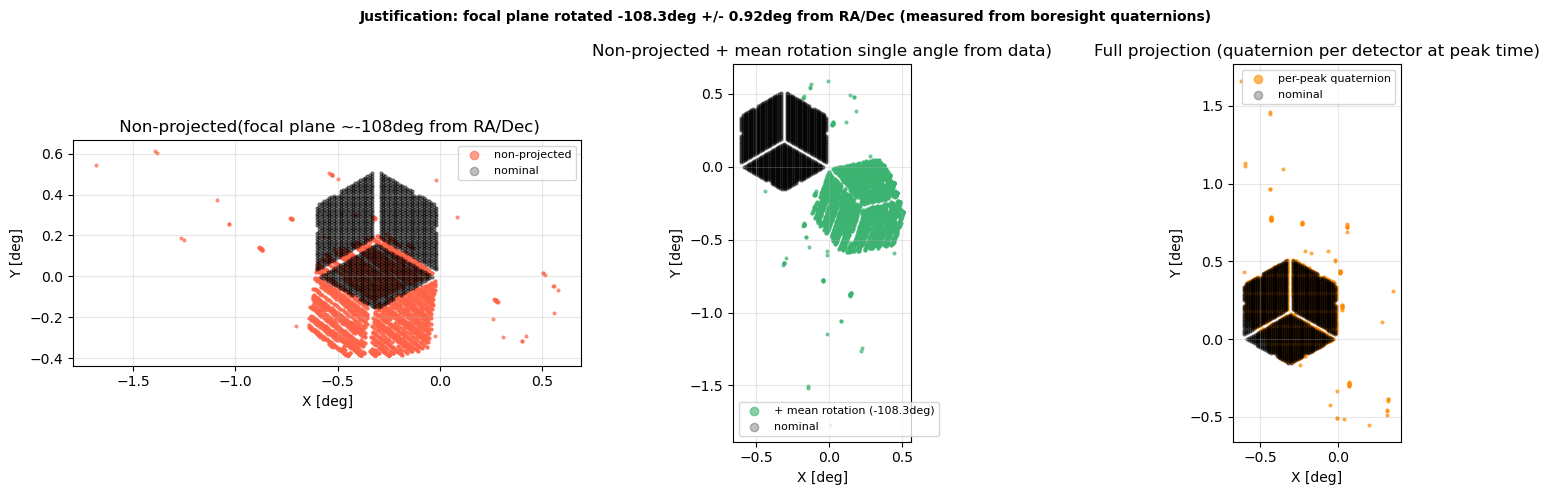

Residual (mean rotation vs per-sample quaternion):
  X std=18.888 arcmin   Y std=21.291 arcmin
  Non-zero residual reflects the 0.92deg variation across the scan


In [28]:
### Why the projection matters: position angle measured from the data

# The boresight quaternion rotates the telescope frame into the equatorial frame.
# The angle its x-axis makes with the RA direction is the position angle of the
# focal plane on the sky. We measure it directly from peak_bq at each detector's peak time.

r_peaks = Rotation.from_quat(peak_bq[tb_valid])
x_hat   = r_peaks.apply([1., 0., 0.])   # focal plane x-axis in equatorial frame

psi_deg = np.degrees(np.arctan2(x_hat[:, 1], x_hat[:, 0]))
print(f"Position angle of focal plane x-axis (from data):")
print(f"  mean  = {psi_deg.mean():.2f} deg")
print(f"  std   = {psi_deg.std():.2f} deg  (variation across scan)")
print(f"  range = {psi_deg.max() - psi_deg.min():.2f} deg")
print(f"Focal plane is rotated ~{psi_deg.mean():.0f}deg from RA/Dec.")
print(f"  This is why raw RA/Dec offsets cannot be compared directly to (xi, eta).")

# Apply the MEAN rotation to non-projected offsets and compare to full per-sample result
psi_mean = np.radians(psi_deg.mean())
c, s = np.cos(-psi_mean), np.sin(-psi_mean)
rx, ry = raw_x[tb_valid], raw_y[tb_valid]
raw_x_rot =  c * rx - s * ry
raw_y_rot =  s * rx + c * ry

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(raw_x[tb_valid], raw_y[tb_valid], s=4, c="tomato", alpha=0.6, label="non-projected")
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c="k", alpha=0.25, label="nominal")
ax.set_title(f" Non-projected(focal plane ~{psi_deg.mean():.0f}deg from RA/Dec)")
ax.set_xlabel("X [deg]"); ax.set_ylabel("Y [deg]"); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.legend(markerscale=3, fontsize=8)

ax = axes[1]
ax.scatter(raw_x_rot, raw_y_rot, s=4, c="mediumseagreen", alpha=0.6, label=f"+ mean rotation ({psi_deg.mean():.1f}deg)")
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c="k", alpha=0.25, label="nominal")
ax.set_title(f"Non-projected + mean rotation single angle from data)")
ax.set_xlabel("X [deg]"); ax.set_ylabel("Y [deg]"); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.legend(markerscale=3, fontsize=8)

ax = axes[2]
ax.scatter(time_x[tb_valid], time_y[tb_valid], s=4, c="darkorange", alpha=0.6, label="per-peak quaternion")
ax.scatter(nom_x_sel[tb_valid], nom_y_sel[tb_valid], s=4, c="k", alpha=0.25, label="nominal")
ax.set_title(f"Full projection (quaternion per detector at peak time)")
ax.set_xlabel("X [deg]"); ax.set_ylabel("Y [deg]"); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.legend(markerscale=3, fontsize=8)

fig.suptitle(f"Justification: focal plane rotated {psi_deg.mean():.1f}deg +/- {psi_deg.std():.2f}deg from RA/Dec (measured from boresight quaternions)",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

diff_x = (raw_x_rot - time_x[tb_valid]) * 60
diff_y = (raw_y_rot - time_y[tb_valid]) * 60
print(f"Residual (mean rotation vs per-sample quaternion):")
print(f"  X std={diff_x.std():.3f} arcmin   Y std={diff_y.std():.3f} arcmin")
print(f"  Non-zero residual reflects the {psi_deg.std():.2f}deg variation across the scan")

##  Method comparison between map and time

Detectors valid in both methods: 3426 / 3426
Method A (map)  : X: mean=0.98 std=3.70  Y: mean=0.66 std=2.87 arcmin
Method B (time) : X: mean=1.09 std=4.93  Y: mean=0.74 std=5.92 arcmin


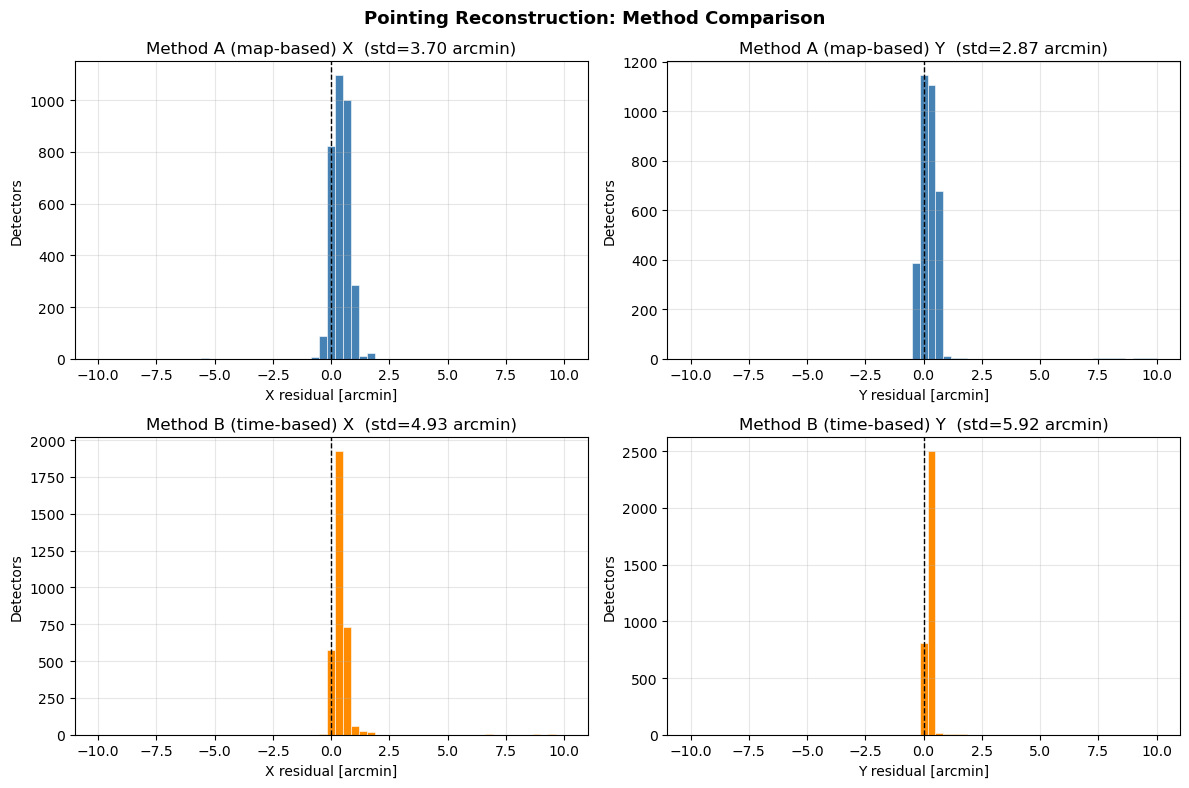

In [29]:

# Detectors valid in both methods
both_valid = valid & tb_valid   # valid = from map-based (cell above); tb_valid = from time-based

dx_map = (recon_x[both_valid] - nom_x_sel[both_valid]) * 60   # arcmin
dy_map = (recon_y[both_valid] - nom_y_sel[both_valid]) * 60
dx_tb2 = (time_x[both_valid]  - nom_x_sel[both_valid]) * 60
dy_tb2 = (time_y[both_valid]  - nom_y_sel[both_valid]) * 60

print(f'Detectors valid in both methods: {both_valid.sum()} / {n_sel}')
print(f'Method A (map)  : X: mean={dx_map.mean():.2f} std={dx_map.std():.2f}  '
      f'Y: mean={dy_map.mean():.2f} std={dy_map.std():.2f} arcmin')
print(f'Method B (time) : X: mean={dx_tb2.mean():.2f} std={dx_tb2.std():.2f}  '
      f'Y: mean={dy_tb2.mean():.2f} std={dy_tb2.std():.2f} arcmin')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
bins = np.linspace(-10, 10, 60)

for row, (dx, dy, label, color) in enumerate([
    (dx_map, dy_map, 'Method A (map-based)',  'steelblue'),
    (dx_tb2, dy_tb2, 'Method B (time-based)', 'darkorange'),
]):
    for col, (vals, axis_label) in enumerate([(dx, 'X'), (dy, 'Y')]):
        ax = axes[row, col]
        ax.hist(vals, bins=bins, color=color, edgecolor='white', linewidth=0.4)
        ax.axvline(0, color='k', linestyle='--', linewidth=1)
        ax.set_xlabel(f'{axis_label} residual [arcmin]')
        ax.set_ylabel('Detectors')
        ax.set_title(f'{label} {axis_label}  (std={vals.std():.2f} arcmin)')
        ax.grid(alpha=0.3)
#
fig.suptitle('Pointing Reconstruction: Method Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Method C: From the Mapmaker Itself

Instead of recomputing per-detector maps from the raw G3 files, load centroids.json from a production run_mapmaker.py run with per_detector.apply_offsets = false (bins each detector against the shared boresight a_bore/dec_bore, no per-detector offset applied). This skips the ~750s streaming pass entirely centroids.json is just a JSON file.

NOTE: This does not currently produce a precise focal-plane offset, and shouldn't be trusted for real numbers. Converting peak_ra_deg/peak_dec_deg into a focal-plane offset needs a rotation to undo the boresight orientation but centroids.json's map is accumulated over the whole observation window, and if the scan makes multiple passes over the region, a given detector can register its peak on more than one pass, each at a different boresight orientation. The peak pixel is then some blend of those passes, not a single clean geometric point. 

The per detector maps aren't accurate , we need to sore the boresight quaternion at each detector's specific peak sample.

Loaded 3426 detector centroids from jupiter_d3426_2026-07-15_16-02-13 (no recomputation)
Representative position angle: mean=-108.82 deg, std=1.03 deg (over this window)
Valid (SNR > 3, has nominal): 3132 / 3426
Method C residuals (3132 detectors):
  X: mean=4.73  std=3.05 arcmin
  Y: mean=5.08  std=2.93 arcmin
  (still larger than Method A/B production run used a 100s window, not the full observation)


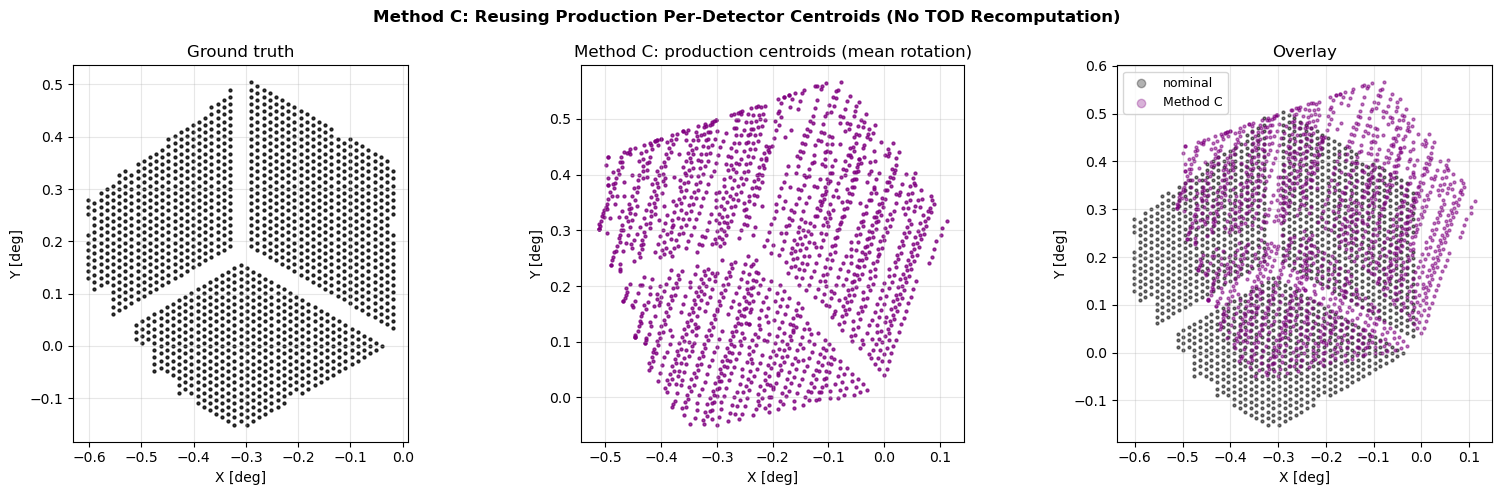

In [30]:
import json

PROD_RUN_DIR = pathlib.Path('../output/jupiter_d3426_2026-07-15_16-02-13').resolve()

with open(PROD_RUN_DIR / 'per_detector' / 'centroids.json') as f:
    centroids = json.load(f)
with open(PROD_RUN_DIR / 'metadata.json') as f:
    prod_meta = json.load(f)
print(f'Loaded {len(centroids)} detector centroids from {PROD_RUN_DIR.name} (no recomputation)')

# Representative boresight position angle for the SAME time window used to produce
# centroids.json (see metadata.json: pipeline_start_offset_s / pipeline_max_duration_s).
# Cheap: only reads boresight_q per chunk, no signal binning.
cfg_c = dict(cfg)
cfg_c['pipeline'] = dict(cfg['pipeline'])
cfg_c['pipeline']['start_offset_s'] = prod_meta['pipeline_start_offset_s']
cfg_c['pipeline']['max_duration_s']  = prod_meta['pipeline_max_duration_s']

psi_list = []
for chunk in iter_g3_chunks(cfg_c):
    r = Rotation.from_quat(chunk.boresight_q)
    x_hat = r.apply([1., 0., 0.])
    psi_list.append(np.degrees(np.arctan2(x_hat[:, 1], x_hat[:, 0])))
psi_all = np.concatenate(psi_list)
psi_mean_c = np.radians(psi_all.mean())
print(f'Representative position angle: mean={np.degrees(psi_mean_c):.2f} deg, '
      f'std={psi_all.std():.2f} deg (over this window)')

# Convert each detector's recovered sky centroid into a focal-plane offset,
# using the mean rotation (same approximation as psi_justification above).
#
# Sign convention: centroids.json's peak_ra/dec_deg is the boresight's own sky
# position at the map's peak bin (built by binning against ra_bore/dec_bore),
# NOT a single-sample "boresight when this detector saw Jupiter" like Method B's
# peak_ra_b so the offset is (recovered - assumed source), the opposite sign
# from Method B's (RA_SRC - peak_ra_b). Verified numerically against nominal below.
names_c = list(centroids.keys())
ra_c    = np.array([centroids[n]['peak_ra_deg']  for n in names_c])
dec_c   = np.array([centroids[n]['peak_dec_deg'] for n in names_c])
snr_c   = np.array([centroids[n]['peak_snr']     for n in names_c])

cos_dec_c = np.cos(np.radians(DEC_SRC))
raw_x_c = (ra_c  - RA_SRC)  * cos_dec_c
raw_y_c = (dec_c - DEC_SRC)

c_, s_ = np.cos(-psi_mean_c), np.sin(-psi_mean_c)
prod_x = c_ * raw_x_c - s_ * raw_y_c
prod_y = s_ * raw_x_c + c_ * raw_y_c

nom_x_c = np.array([nominal[n][0] if n in nominal else np.nan for n in names_c])
nom_y_c = np.array([nominal[n][1] if n in nominal else np.nan for n in names_c])
prod_valid = np.isfinite(nom_x_c) & (snr_c > 3.0)
print(f'Valid (SNR > 3, has nominal): {prod_valid.sum()} / {len(names_c)}')

dx_prod = (prod_x[prod_valid] - nom_x_c[prod_valid]) * 60
dy_prod = (prod_y[prod_valid] - nom_y_c[prod_valid]) * 60
print(f'Method C residuals ({prod_valid.sum()} detectors):')
print(f'  X: mean={dx_prod.mean():.2f}  std={dx_prod.std():.2f} arcmin')
print(f'  Y: mean={dy_prod.mean():.2f}  std={dy_prod.std():.2f} arcmin')
print('  (still larger than Method A/B production run used a 100s window, not the full observation)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
ax.scatter(nom_x_c[prod_valid], nom_y_c[prod_valid], s=4, c='k', alpha=0.5)
ax.set_title('Ground truth')

ax = axes[1]
ax.scatter(prod_x[prod_valid], prod_y[prod_valid], s=4, c='purple', alpha=0.5)
ax.set_title('Method C: production centroids (mean rotation)')

ax = axes[2]
ax.scatter(nom_x_c[prod_valid], nom_y_c[prod_valid], s=4, c='k', alpha=0.3, label='nominal')
ax.scatter(prod_x[prod_valid],  prod_y[prod_valid],  s=4, c='purple', alpha=0.3, label='Method C')
ax.set_title('Overlay')
ax.legend(markerscale=3, fontsize=9)

for a in axes:
    a.set_xlabel('X [deg]'); a.set_ylabel('Y [deg]')
    a.set_aspect('equal'); a.grid(alpha=0.3)

fig.suptitle('Method C: Reusing Production Per-Detector Centroids (No TOD Recomputation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Next Steps:

- I want to explore how many passes it would take to to decently reconstruct everything.
- I also want to implement something to be able to check asymmetry offsets (right passes vs left passes) for the real data